# P02 — Concentraciones de incidentes de Bomberos de Bogotá

## Objetivos
1. Evaluar cobertura, campos, nulos, claves, coordenadas y tiempo antes de modelar.
2. Comparar DBSCAN, HDBSCAN y OPTICS con mapas y gráficos nativos ArcGIS.
3. Obtener centros medios DBSCAN y sus coincidencias jurisdiccionales, preservando ambigüedades y conteos.
4. Distinguir concentración de registros, incertidumbre de pertenencia y riesgo: no son equivalentes.

**Pregunta:** ¿dónde se concentran los registros disponibles y cómo cambia su agrupación según el método? No se estiman tasas poblacionales, causas, cobertura operativa ni tiempos de respuesta. La unidad es una fila, no necesariamente un evento único.

**Requisitos:** ArcGIS Pro 3.6 con licencia Advanced para Identity, entorno Python de Pro y entradas locales autorizadas. Reiniciar kernel y ejecutar todo; no requiere ModelBuilder, proyecto abierto, conexión de red ni otro notebook. pandas organiza tablas pequeñas y agregados; ArcPy realiza geoprocesamiento, mapas y gráficos.

### Configuración única
Cambie solamente las tres rutas siguientes si usa unidades externas. DATA_DIR contiene la GDB de incidentes; PREPARED_JURIS apunta a la entidad jurisdiccional preparada por separado. OUTPUT_DIR debe ser independiente de ambas entradas. Las entradas nunca se editan; cada ejecución crea una carpeta nueva. La búsqueda de ROOT facilita abrir este notebook desde el vault o su carpeta notebooks.

**Ejecución observada de esta revisión:** 26/26 celdas; 153.439 s; 14 PNG incrustados; retorno natural **0**. Proceso Python de ArcGIS Pro con captura MIME; no prueba una sesión interactiva Jupyter/VS Code. Carpeta: `ejecucion_20260916T221040_d407aea3`.

**Presentación aún en revisión:** faltan ajustes y comprobaciones visuales; esto no es entrega académica final. La licencia bloqueó la continuación de las dos últimas prácticas. La captura sin InteractiveShell evitó el error fatal GIL en tres procesos, pero no certifica un kernel interactivo sano.

**Aclaración de color de esta exportación:** en el mapa EDA, los incidentes aparecen en verde azulado; el texto histórico que los describe como azules no cambia qué filas representan. En clustering, gris significa ruido; no equivale al gris no significativo de Gi*.

### Convención visual y conexión
Fondo claro; títulos Cambria y texto Segoe UI en mapas. Colores de grupos nominales, sin orden de riesgo. La base **Light Gray Canvas**, seleccionada del catálogo ArcGIS, aporta nombres y vías de contexto de Esri y colaboradores; la atribución está dentro del marco. **Solo la base requiere conexión**: análisis, datos y PNG incrustados son locales. No modifica coordenadas ni pesos. Si el contexto no carga, el mapa no queda verificado.

En curvas z de Moran, 0 y ±1.96 son referencias **nominales de una prueba fijada**, no corrección FDR ni confirmación tras explorar bandas. Consulte todos los valores en la tabla.

### Configuración y estado de esta revisión
La primera celda solo define rutas. `ROOT = None` busca ambos marcadores desde la carpeta actual o sus ancestros. Si Jupyter inicia fuera del vault, sustituya **esa primera asignación** por `ROOT = Path(...)` con la ruta absoluta de su copia; no use `__file__`. `DATA_DIR` y `OUTPUT_DIR` admiten rutas externas absolutas: cambie sus asignaciones aquí y mantenga entradas y salidas separadas. En Bomberos P02, `PREPARED_JURIS` configura la entrada preparada por separado. La plantilla se obtiene de la instalación de Pro. El preflight muestra nombre, ruta resuelta y existencia antes de crear salidas; no instala ArcPy ni obtiene licencia automáticamente.

**Estado N02:** salidas y cifras incrustadas son **históricas, referencia histórica; cotejar con salida actual** (ejecución final completa). Las pruebas de rutas no ejecutan modelos. Pendientes N03 (visualización) y N05 (verificación independiente). Se conservan registros previos: cero errores de celda no demuestra cierre natural; el cierre forzado del driver histórico de Clase 02 tampoco lo acredita.


In [1]:
# ROOT=None busca el vault; fuera de él escriba aquí Path con su ruta absoluta.
from pathlib import Path
ROOT = None
ROOT = Path(ROOT).expanduser().resolve() if ROOT is not None else next((p for p in (Path.cwd(), *Path.cwd().parents) if (p/'AGENTS.md').is_file() and (p/'99 - Recursos/notebooks').is_dir()), None)
if ROOT is None or not (ROOT/'AGENTS.md').is_file() or not (ROOT/'99 - Recursos/notebooks').is_dir():
    raise FileNotFoundError('No se encontró el vault (AGENTS.md + 99 - Recursos/notebooks). Edite ROOT = Path con la ruta absoluta del vault; no use __file__.')
DATA_DIR = ROOT / 'Datos'
OUTPUT_DIR = ROOT / '99 - Recursos/salidas_clase_01/practica_02'
PREPARED_JURIS = ROOT / '99 - Recursos/datos/p02_jurisdicciones_preparadas/jurisdicciones.gdb/Jurisdicciones_Bomberos'


### Preflight de solo lectura
Comprobar kernel, licencia y requisitos antes de crear salidas. Cada ausencia se informa por su nombre y ruta exactos.

In [2]:
# Solo lectura: comprobar kernel, licencia y cada ruta antes de crear salidas.
try:
    import arcpy
except Exception as exc:
    raise RuntimeError('ArcPy no disponible. Seleccione el kernel Python de ArcGIS Pro con licencia y reinícielo; no se instala automáticamente.') from exc
try:
    INFO_PRO = arcpy.GetInstallInfo()
    LICENCIA = arcpy.ProductInfo()
except Exception as exc:
    raise RuntimeError('No se pudo inicializar Pro. Revise instalación y acceso a licencia antes de modelar.') from exc
print('ArcGIS Pro:', INFO_PRO.get('Version'), '| licencia:', LICENCIA)
if LICENCIA not in ('ArcView', 'ArcEditor', 'ArcInfo'):
    raise RuntimeError('Licencia no inicializada: ' + str(LICENCIA))
PLANTILLA = Path(INFO_PRO['InstallDir']) / 'Resources/ArcToolBox/Services/routingservices/data/Blank.aprx'
ORIGINAL = DATA_DIR / 'Datos Ejercicio5A.gdb/Incidentes_Bomberos'
REQUERIDOS = [('Incidentes_Bomberos', ORIGINAL, False), ('Jurisdicciones_Bomberos preparada', PREPARED_JURIS, False), ('Blank.aprx instalada', PLANTILLA, True)]
faltantes = []
for nombre, ruta, es_archivo in REQUERIDOS:
    ruta = Path(ruta).resolve()
    existe = ruta.is_file() if es_archivo else bool(arcpy.Exists(str(ruta)))
    print(f'{nombre} | {ruta} | existe={existe}')
    if not existe:
        faltantes.append(f'{nombre}: {ruta}')
if faltantes:
    raise FileNotFoundError('Entradas ausentes; ajuste la configuración sin sustituir datos: ' + '; '.join(faltantes))
if LICENCIA != 'ArcInfo':
    raise RuntimeError('Identity requiere Advanced (ArcInfo); licencia observada: ' + str(LICENCIA))


ArcGIS Pro: 3.6.2 | licencia: ArcInfo
Incidentes_Bomberos | C:\Users\ecetina\OneDrive - Esri NOSA\diplomado_geoia_v3\Datos\Datos Ejercicio5A.gdb\Incidentes_Bomberos | existe=True
Jurisdicciones_Bomberos preparada | C:\Users\ecetina\OneDrive - Esri NOSA\diplomado_geoia_v3\99 - Recursos\datos\p02_jurisdicciones_preparadas\jurisdicciones.gdb\Jurisdicciones_Bomberos | existe=True
Blank.aprx instalada | C:\Program Files\ArcGIS\Pro\Resources\ArcToolBox\Services\routingservices\data\Blank.aprx | existe=True


**Lectura:** `existe=True` indica disponibilidad, no calidad geométrica ni resultados. **Compruebe:** ¿usa el kernel de Pro y la entrada autorizada?

## 1. Entorno y protección de entradas
La salida se aísla antes de cualquier operación. La GDB preparada es una entrada de solo lectura: si CheckGeometry encuentra problemas, la práctica se detiene. La integridad binaria excluye únicamente archivos transitorios `.lock`. No se modifican atributos ni geometrías originales.

La plantilla vacía procede de la instalación de Esri; se abre por archivo, nunca mediante un proyecto activo. Fuente: Esri, ArcGIS Pro 3.6, [ArcGISProject, constructor y saveACopy](https://pro.arcgis.com/en/pro-app/3.6/arcpy/mapping/arcgisproject-class.htm), documentación verificada el 2026-09-15.

In [3]:
# Bibliotecas del entorno Pro; ninguna función depende de auxiliares del curso.
import arcpy, os, json, math, time, hashlib, uuid, platform
from collections import Counter
from datetime import datetime, timezone
import pandas as pd
from IPython.display import display, Markdown, Image
inicio = time.perf_counter()
TIEMPOS, PNG, METRICAS = {}, [], {}
ENTRADAS = {'gdb': ORIGINAL.parent, 'preparada': PREPARED_JURIS.parent, 'plantilla': PLANTILLA}
ENTORNO = {'arcgis_pro': arcpy.GetInstallInfo()['Version'], 'python': platform.python_version(), 'licencia': arcpy.ProductInfo()}
if arcpy.ProductInfo() != 'ArcInfo':
    raise RuntimeError('Identity requiere licencia Advanced disponible.')
display(ENTORNO)

{'arcgis_pro': '3.6.2', 'python': '3.13.7', 'licencia': 'ArcInfo'}

### Identidad de ejecución
Un nombre nuevo evita sobrescribir ensayos anteriores. Si el lanzador suministra una identidad, se acepta solo dentro de OUTPUT_DIR. La comparación de rutas resueltas protege también frente a alias que apunten a entradas. El temporizador registra operaciones computacionales, no duración docente.

In [4]:
# Separar destinos de los datos, la plantilla y cualquier geodatabase de entrada.
output = OUTPUT_DIR.resolve()
for original in [DATA_DIR.resolve(), *(p.resolve() for p in ENTRADAS.values())]:
    if output == original or output in original.parents or original in output.parents:
        raise ValueError('Entradas y salidas deben estar completamente separadas.')
if any(p.suffix.lower() == '.gdb' for p in [output, *output.parents]):
    raise ValueError('OUTPUT_DIR no puede estar dentro de una geodatabase.')
selected = os.environ.get('GEOIA_P02_RUN')
if selected:
    RUN = Path(selected).resolve()
    if RUN.parent != output or not RUN.is_dir() or not RUN.name.startswith('ejecucion_'):
        raise ValueError('Identidad de ejecución fuera de OUTPUT_DIR.')
else:
    RUN = output / ('ejecucion_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S') + '_' + uuid.uuid4().hex[:8])
    RUN.mkdir(parents=True, exist_ok=False)
arcpy.env.overwriteOutput = False
arcpy.env.parallelProcessingFactor = '0'
arcpy.env.workspace = arcpy.env.scratchWorkspace = str(RUN)
arcpy.SetLogHistory(False)
arcpy.SetLogMetadata(False)
arcpy.management.CreateFileGDB(str(RUN), 'trabajo.gdb')
GDB = RUN / 'trabajo.gdb'
print('Ejecución:', RUN.name)

Ejecución: ejecucion_20260916T221040_d407aea3


### Comprobación y funciones pequeñas
SHA-256 permite detectar cambios de bytes, no certificar calidad temática ni derechos de los datos. La medición por herramienta incluye su ejecución y conserva el tiempo aunque una operación falle. Los archivos de integridad se escriben en la salida nueva.

In [5]:
# Firmas de contenido sin guardar rutas personales en la evidencia pública local.
def fingerprint(path):
    path = Path(path)
    digest = hashlib.sha256()
    files = [path] if path.is_file() else sorted(p for p in path.rglob('*') if p.is_file() and p.suffix.lower() != '.lock')
    if not files:
        raise ValueError('Entrada sin archivos para comprobar integridad.')
    for file in files:
        digest.update((file.name if path.is_file() else file.relative_to(path).as_posix()).encode())
        with file.open('rb') as stream:
            for block in iter(lambda: stream.read(1024 * 1024), b''):
                digest.update(block)
    return {'sha256': digest.hexdigest(), 'archivos': len(files)}

def medir(nombre, funcion, *args, **kwargs):
    inicio_herramienta = time.perf_counter()
    try:
        return funcion(*args, **kwargs)
    finally:
        TIEMPOS[nombre] = time.perf_counter() - inicio_herramienta

HASHES_ANTES = {k: fingerprint(p) for k, p in ENTRADAS.items()}
(RUN / 'integridad_notebook_antes.json').write_text(json.dumps({'run_id': RUN.name, 'hashes': HASHES_ANTES}, indent=2), encoding='utf-8')
print('Entradas protegidas:', list(HASHES_ANTES))

Entradas protegidas: ['gdb', 'preparada', 'plantilla']


## 2. EDA antes del clustering: qué representa cada campo
El número de incidente es un identificador, no una magnitud para promediar. La estación reportada no equivale automáticamente a la jurisdicción atribuida por una unión espacial heredada. Se inspeccionan ambos campos y se conservan sus diferencias. Las coordenadas pertenecen al CRS de los datos; no se estandarizan metros ni se reasigna una proyección.

**Data Engineering** es una vista de ArcGIS Pro, no una función ArcPy. Aquí usamos su alternativa programática reproducible: ListFields, cursores, FieldStatisticsToTable y gráficos nativos sobre copias. Abrir esa vista manualmente es opcional, no requisito. Esri, Pro 3.6, [Field Statistics To Table, Parameters/Python](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/data-management/field-statistics-to-table.htm), consulta verificada 2026-09-15.

In [6]:
# Diccionario de los campos realmente empleados; significado separado del tipo físico.
FECHA = 'IncidentesBomberos_FECHA'
NUMERO = 'IncidentesBomberos_NUMERO_INC'
ESTACION = 'IncidentesBomberos_ESTACION'
JURIS_EST = 'Incidentes_Bomberos_AddSpatialJoin_ESTACION'
SIGNIFICADOS = {FECHA: 'Fecha registrada; no garantiza hora ni exhaustividad temporal.',
    NUMERO: 'Identificador reportado; nulo o repetido no prueba evento duplicado.',
    ESTACION: 'Estación reportada en el registro; no certifica despacho.',
    JURIS_EST: 'Código de jurisdicción heredado de unión espacial; no recalculado aquí.'}
diccionario = [{'campo': f.name, 'tipo': f.type, 'longitud': f.length, 'significado': SIGNIFICADOS[f.name]}
               for f in arcpy.ListFields(str(ORIGINAL)) if f.name in SIGNIFICADOS]
if len(diccionario) != len(SIGNIFICADOS):
    raise RuntimeError('Falta un campo requerido; no se infieren nombres.')
display(pd.DataFrame(diccionario))
JURIS_CAMPOS = ['ESTACION', 'NOMBRE_EST', 'COMPAÑIA', 'NOMBRE_CORTO_EST']
display(pd.DataFrame([{'campo': f.name, 'tipo': f.type, 'alias': f.aliasName}
                     for f in arcpy.ListFields(str(PREPARED_JURIS)) if f.name in JURIS_CAMPOS]))
with arcpy.da.SearchCursor(str(PREPARED_JURIS), JURIS_CAMPOS) as cursor:
    jurisdicciones = pd.DataFrame(list(cursor), columns=JURIS_CAMPOS)
display(jurisdicciones)

,campo,tipo,longitud,significado
0,IncidentesBomberos_FECHA,Date,8,Fecha registrada; no garantiza hora ni exhaust...
1,IncidentesBomberos_NUMERO_INC,Double,8,Identificador reportado; nulo o repetido no pr...
2,IncidentesBomberos_ESTACION,String,254,Estación reportada en el registro; no certific...
3,Incidentes_Bomberos_AddSpatialJoin_ESTACION,String,10,Código de jurisdicción heredado de unión espac...


,campo,tipo,alias
0,ESTACION,String,Código de Estación
1,NOMBRE_EST,String,Nombre Estación
2,COMPAÑIA,String,Compañia
3,NOMBRE_CORTO_EST,String,Nombre Corto


,ESTACION,NOMBRE_EST,COMPAÑIA,NOMBRE_CORTO_EST
0,B-6,Estación de Bomberos Fontibón - Alexander Marí...,COMPAÑIA II,Fontibón
1,B-4,Estación de Bomberos Puente Aranda - Alberto A...,COMPAÑIA III,Puente Aranda
2,B-2,Estación de Bomberos Central - Carlos Julio Ri...,COMPAÑIA III,Central
3,B-1,Estación de Bomberos Chapinero - Miguel Ángel ...,COMPAÑIA I,Chapinero
4,B-8,Estación de Bomberos de Bosa,COMPAÑIA V,Bosa
5,B-12,Estación de Bomberos Suba,COMPAÑIA II,Suba
6,B-10,Estación de Bomberos Marichuela,COMPAÑIA IV,Marichuela
7,B-15,Estación de Bomberos Garcés Navas,COMPAÑIA II,Garcés Navas
8,B-3,Estación de Bomberos Restrepo - José Demetrio ...,COMPAÑIA IV,Restrepo
9,B-14,Estación de Bomberos Bicentenario de la Indepe...,COMPAÑIA I,Bicentenariola Independencia


**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** Cuatro campos: fecha Date, identificador Double y dos categorías String. Hay 17 jurisdicciones; B-3 identifica Restrepo. Los códigos no tienen unidad cuantitativa; no se publican identificadores individuales. COMPAÑIA es categoría, sin inferir función operativa exacta del nombre. Longitud es capacidad del campo, no longitud observada. ¿Por qué no promediar NUMERO_INC aunque sea Double?

### Nulos, ceros y repetición no son lo mismo
Se cuentan ausencias por campo, identificadores iguales y pares XY repetidos. Un número repetido podría corresponder a varios servicios o a un problema de captura; un XY repetido podría ser una localización frecuente o geocodificación común. Sin evidencia adicional no se elimina ninguna fila. Se evalúan fechas mínimas/máximas y distribución anual, pero un rango completo no demuestra que todos los eventos estén presentes.

In [7]:
# Perfil agregado de solo lectura: no se imprimen incidentes individuales ni coordenadas.
def perfil(fc):
    fields = [FECHA, NUMERO, ESTACION, JURIS_EST, 'SHAPE@XY']
    ids, xy, estaciones, zonas, anios = (Counter() for _ in range(5))
    nulos = dict.fromkeys(fields[:4], 0)
    fechas, no_finitas, filas, ceros = [], 0, 0, 0
    for_values = arcpy.da.SearchCursor(str(fc), fields)
    with for_values as cursor:
        for fecha, numero, estacion, zona, point in cursor:
            filas += 1
            for field, value in zip(fields, [fecha, numero, estacion, zona]):
                nulos[field] += value is None or value == ''
            if fecha is not None:
                fechas.append(fecha); anios[str(fecha.year)] += 1
            if numero is not None:
                ids[numero] += 1; ceros += numero == 0
            estaciones[str(estacion) if estacion else '(sin dato)'] += 1
            zonas[str(zona) if zona else '(sin dato)'] += 1
            if point is None or not all(v is not None and math.isfinite(v) for v in point):
                no_finitas += 1
            else:
                xy[point] += 1
    repetidas = lambda c: {'distintas': len(c), 'claves_repetidas': sum(v > 1 for v in c.values()), 'filas_excedentes': sum(v - 1 for v in c.values())}
    sr = arcpy.Describe(str(fc)).spatialReference
    return {'filas': filas, 'nulos': nulos, 'id_cero': ceros, 'ids_no_nulos': repetidas(ids),
        'xy': repetidas(xy), 'xy_no_finitas': no_finitas, 'fecha_min': min(fechas).isoformat() if fechas else None,
        'fecha_max': max(fechas).isoformat() if fechas else None, 'estaciones': dict(sorted(estaciones.items())),
        'jurisdiccion_heredada': dict(sorted(zonas.items())), 'anios': dict(sorted(anios.items())),
        'wkid': sr.factoryCode, 'crs': sr.name, 'unidades': sr.linearUnitName}
PERFIL_ANTES = perfil(ORIGINAL)
display(PERFIL_ANTES)

{'filas': 90443,
 'nulos': {'IncidentesBomberos_FECHA': 0,
  'IncidentesBomberos_NUMERO_INC': 60711,
  'IncidentesBomberos_ESTACION': 0,
  'Incidentes_Bomberos_AddSpatialJoin_ESTACION': 0},
 'id_cero': 0,
 'ids_no_nulos': {'distintas': 29165,
  'claves_repetidas': 494,
  'filas_excedentes': 567},
 'xy': {'distintas': 82770,
  'claves_repetidas': 5670,
  'filas_excedentes': 7673},
 'xy_no_finitas': 0,
 'fecha_min': '2022-01-01T00:00:00',
 'fecha_max': '2024-12-31T00:00:00',
 'estaciones': {'B-1  CHAPINERO': 7260,
  'B-10  MARICHUELA': 4382,
  'B-11 LA CANDELARIA': 6219,
  'B-12  SUBA': 5839,
  'B-13  CAOBOS SALAZAR': 7706,
  'B-14  BICENTENARIOLA INDEPENDENCIA': 5250,
  'B-15  GARCÉS NAVAS': 5369,
  'B-16 VENECIA': 3218,
  'B-17  CENTRO HISTÓRICO': 3087,
  'B-2  CENTRAL': 4677,
  'B-3  RESTREPO': 4802,
  'B-4  PUENTE ARANDA': 3669,
  'B-5 KENNEDY': 8705,
  'B-6  FONTIBÓN': 4441,
  'B-7  FERIAS': 6205,
  'B-8 BOSA': 5169,
  'B-9  BELLAVISTA': 4445},
 'jurisdiccion_heredada': {'B-1': 7260

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** 90 443 filas, 60 711 identificadores ausentes y 0 identificadores cero: ausencia no es cero. Hay 494 claves repetidas y 5 670 XY repetidas; 82 770 posiciones distintas no representan todo el territorio. Fechas 2022-01-01 a 2024-12-31; CRS 9377, metros. Conclusión: cobertura registrada, no exhaustividad. ¿Una clave repetida prueba un evento duplicado?

### Copia analítica y puerta geométrica
Se copian todos los incidentes sin filtrar ni imputar. CheckGeometry comprueba la copia de puntos y la jurisdicción preparada, guardando sus tablas en la salida. Cero problemas significa que esta comprobación no detectó errores, no que la geocodificación o los límites sean legalmente correctos.

Esri, Pro 3.6, [Copy Features, Python](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/data-management/copy-features.htm) y [Check Geometry, Usage/Python](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/data-management/check-geometry.htm), consulta verificada 2026-09-15.

In [8]:
# Modelar solo una copia íntegra; detenerse ante cualquier problema geométrico.
PUNTOS = str(GDB / 'Incidentes_copia')
medir('CopyFeatures_entrada', arcpy.management.CopyFeatures, str(ORIGINAL), PUNTOS)
PERFIL_DESPUES = perfil(PUNTOS)
if PERFIL_ANTES != PERFIL_DESPUES:
    raise RuntimeError('La copia no conserva el perfil de entrada.')
sr = arcpy.Describe(PUNTOS).spatialReference
sr_juris = arcpy.Describe(str(PREPARED_JURIS)).spatialReference
if sr.factoryCode != 9377 or sr_juris.factoryCode != sr.factoryCode or sr.linearUnitName.lower() not in ('meter', 'metre'):
    raise RuntimeError('CRS/unidades distintos del contrato comprobado; no se reproyecta automáticamente.')
GEOMETRIA = {}
for nombre, entidad in [('puntos', PUNTOS), ('jurisdicciones_preparadas', str(PREPARED_JURIS))]:
    tabla = str(GDB / ('check_' + nombre))
    medir('CheckGeometry_' + nombre, arcpy.management.CheckGeometry, entidad, tabla, 'ESRI')
    GEOMETRIA[nombre] = int(arcpy.management.GetCount(tabla)[0])
if any(GEOMETRIA.values()) or PERFIL_DESPUES['xy_no_finitas']:
    raise RuntimeError('Geometría inválida: práctica detenida antes de Identity o clustering.')
extension_comun = arcpy.Describe(PUNTOS).extent
display(pd.DataFrame([{'etapa': n, 'filas': p['filas'], 'XY distintos': p['xy']['distintas'],
    'ID nulos': p['nulos'][NUMERO], 'WKID': p['wkid']} for n,p in [('Original',PERFIL_ANTES),('Copia',PERFIL_DESPUES)]]))
print('CheckGeometry:', GEOMETRIA, '; perfiles iguales:', PERFIL_ANTES == PERFIL_DESPUES)

CheckGeometry: {'puntos': 0, 'jurisdicciones_preparadas': 0} ; perfiles iguales: True


,etapa,filas,XY distintos,ID nulos,WKID
0,Original,90443,82770,60711,9377
1,Copia,90443,82770,60711,9377


**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** Se detectaron 0 problemas en puntos/jurisdicciones y perfiles iguales antes/después. La copia conserva ese perfil y supera esta prueba, sin certificar precisión ni límites legales. ¿Puede un punto desplazado pero geométricamente válido pasarla?

### Estadísticas nativas y lectura del diagnóstico
Los descriptivos se limitan a campos pertinentes: conteo, nulos, valores únicos y extremos. No se calcula una media de los números de incidente. La igualdad antes/después documenta una copia, no una limpieza inexistente. Las preguntas sobre Kennedy y Restrepo se responden con la tabla jurisdiccional y con el código de unión espacial heredado, distinguiéndolo de la estación reportada.

In [9]:
# Exportar estadísticas nativas y mostrar respuestas calculadas, no cifras prefijadas.
medir('FieldStatisticsToTable', arcpy.management.FieldStatisticsToTable, PUNTOS,
    [FECHA, NUMERO, ESTACION, JURIS_EST], str(GDB), [['ALL', 'perfil_nativo']],
    out_statistics=[['FIELDNAME', 'campo'], ['FIELDTYPE', 'tipo'], ['COUNT', 'conteo'],
                    ['NULLS', 'nulos'], ['NUMBEROFUNIQUEVALUES', 'unicos'], ['MINIMUM', 'minimo'], ['MAXIMUM', 'maximo']])
with arcpy.da.SearchCursor(str(GDB / 'perfil_nativo'), ['campo','tipo','conteo','nulos','unicos','minimo','maximo']) as cursor:
    display(pd.DataFrame(list(cursor), columns=['Campo','Tipo','Conteo','Nulos','Únicos','Mínimo','Máximo']))
respuestas = jurisdicciones[jurisdicciones.NOMBRE_CORTO_EST.str.contains('Kennedy|Restrepo', case=False, na=False) | jurisdicciones.ESTACION.isin(['B-5','B-3'])]
display(respuestas)
print('Recuentos por código jurisdiccional heredado:', {k:v for k,v in PERFIL_DESPUES['jurisdiccion_heredada'].items() if k in ['B-5','B-3']})
display(Markdown(f"**Lectura observada:** {PERFIL_DESPUES['filas']:,} filas; {PERFIL_DESPUES['nulos'][NUMERO]:,} identificadores ausentes y {PERFIL_DESPUES['id_cero']} ceros. Hay {PERFIL_DESPUES['ids_no_nulos']['claves_repetidas']:,} identificadores repetidos y {PERFIL_DESPUES['xy']['claves_repetidas']:,} posiciones repetidas. No se deduplicó. Periodo: {PERFIL_DESPUES['fecha_min']} a {PERFIL_DESPUES['fecha_max']}; no implica exhaustividad."))

Recuentos por código jurisdiccional heredado: {'B-3': 4802, 'B-5': 8705}


,Campo,Tipo,Conteo,Nulos,Únicos,Mínimo,Máximo
0,IncidentesBomberos_FECHA,Date,90443,0,1096,01/01/2022 12:00:00 AM,31/12/2024 12:00:00 AM
1,IncidentesBomberos_NUMERO_INC,Double,29732,60711,29165,2,123695
2,IncidentesBomberos_ESTACION,Text (254),90443,0,17,None,None
3,Incidentes_Bomberos_AddSpatialJoin_ESTACION,Text (10),90443,0,17,None,None


,ESTACION,NOMBRE_EST,COMPAÑIA,NOMBRE_CORTO_EST
8,B-3,Estación de Bomberos Restrepo - José Demetrio ...,COMPAÑIA IV,Restrepo
14,B-5,Estación de Bomberos de Kennedy - Alejandro Lince,COMPAÑIA III,Kennedy


**Lectura observada:** 90,443 filas; 60,711 identificadores ausentes y 0 ceros. Hay 494 identificadores repetidos y 5,670 posiciones repetidas. No se deduplicó. Periodo: 2022-01-01T00:00:00 a 2024-12-31T00:00:00; no implica exhaustividad.

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** COUNT de identificadores=29 732 y NULLS=60 711 suman 90 443 filas; 29 165 únicos no son eventos únicos certificados. Extremos 2–123 695 son códigos, no intensidad. Los 1 096 valores de fecha distintos no prueban exhaustividad diaria. B-3=4 802 y B-5=8 705 son registros por código heredado, no tasas. ¿Qué denominador falta para comparar riesgo?

### Recursos visuales nativos reutilizables dentro del notebook
Las barras usan categorías nominales: más altura/longitud significa más registros, no mayor tasa de riesgo. Los CSV contienen únicamente agregados docentes. Los PNG se exportan con `arcpy.charts` y se incrustan en la salida del notebook.

Esri, Pro 3.6, [Bar, Parameters/exportToPNG](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/bar.htm) y [Histogram, Parameters](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/histogram.htm), consulta verificada 2026-09-15.

In [10]:
# Solo presentación: no cambia modelos, datos ni coordenadas.
def base_contextual(project, mapa):
    disponibles = project.listBasemaps()
    elegida = next((v for v in ('Light Gray Canvas', 'Human Geography Map') if v in disponibles), None)
    if elegida is None:
        raise RuntimeError('No hay base neutra disponible; el contexto requiere conexión.')
    mapa.addBasemap(elegida)
    print('Base en línea:', elegida, '| Esri y colaboradores; atribución dentro del mapa.')
    return elegida

def texto_atlas(project, layout, geometry, text_type, text, text_size, font_family_name, font_style_name):
    # Ajustar líneas, no reducir pies hasta volverlos ilegibles.
    import textwrap
    ancho = 32 if geometry.X >= 9 else (135 if text_size <= 10 else 80)
    texto = chr(10).join(textwrap.fill(line, width=ancho) for line in text.splitlines())
    return project.createTextElement(layout, geometry, text_type, texto, text_size,
                                     'Cambria' if text_size >= 14 else 'Segoe UI', font_style_name)

def estilo_chart(chart, name):
    # Valor de tema probado mediante exportación real en Pro 3.6.2.
    chart.theme = 'Light'
    chart.displaySize = [1100, 680]
    if name.endswith('_z_score'):
        for valor, etiqueta in [(-1.96, '−1.96 nominal'), (0, 'Referencia nula'), (1.96, '+1.96 nominal')]:
            chart.yAxis.addGuide(arcpy.charts.Guide('line', valueFrom=valor, label=etiqueta,
                                lineColor='#b36b32', lineWidth=1, lineDashStyle='dash'))
        chart.yAxis.minimum = -2.5
    return chart

# Funciones locales para gráficos ArcGIS: ningún reemplazo con otra biblioteca gráfica.
def mostrar_png(path, lectura):
    PNG.append(path.name)
    display(Image(width=1100, filename=str(path)))
    display(Markdown(lectura))

def exportar_chart(chart, nombre, lectura):
    path = RUN / (nombre + '.png')
    medir(nombre, estilo_chart(chart, nombre).exportToPNG, str(path), 1800, 1100)
    mostrar_png(path, lectura)

def barras(conteos, nombre, titulo, lectura):
    tabla = RUN / (nombre + '.csv')
    datos = pd.DataFrame([(str(k), v) for k,v in conteos.items()], columns=['Categoria','Registros'])
    datos['Etiqueta'] = datos.Categoria.str.split().str[0] if nombre == 'arcgis_estaciones' else datos.Categoria
    if not datos.Etiqueta.is_unique:
        raise ValueError('Las etiquetas abreviadas mezclarían categorías distintas.')
    datos.to_csv(tabla, index=False, encoding='utf-8-sig')
    chart = arcpy.charts.Bar(x='Etiqueta', y='Registros', aggregation='SUM', dataSource=str(tabla),
        title=titulo, xTitle='Categoría (nominal)', yTitle='Número de registros', rotated=True)
    exportar_chart(chart, nombre, lectura)

def rectangulo(x0, y0, x1, y1):
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0,y0), arcpy.Point(x1,y0), arcpy.Point(x1,y1), arcpy.Point(x0,y1)]))

### Simbología comparativa
Cada mapa utiliza el CRS real y una extensión común. El ruido se representa en gris; los colores de los grupos son nominales y no establecen equivalencias entre métodos. Los límites preparados sirven para la superposición geométrica, sin certificar jurisdicciones legales.

Esri, Pro 3.6, [UniqueValueRenderer](https://pro.arcgis.com/en/pro-app/3.6/arcpy/mapping/uniquevaluerenderer-class.htm) y [Symbol](https://pro.arcgis.com/en/pro-app/3.6/arcpy/mapping/symbol-class.htm), fields/groups/items y color/size; consulta verificada 2026-09-15.

In [11]:
# Grupos con colores nominales; las etiquetas de leyenda identifican cada valor real.
def simbolizar(layer, clusters=False):
    import colorsys
    sym = layer.symbology
    if clusters:
        sym.updateRenderer('UniqueValueRenderer')
        sym.renderer.fields = ['CLUSTER_ID']
        for group in sym.renderer.groups:
            for item in group.items:
                value = int(item.values[0][0])
                rgb = [110,110,110] if value == -1 else [round(v*255) for v in colorsys.hsv_to_rgb((value*.61803398875)%1,.75,.8)]
                item.label = 'Ruido (-1)' if value == -1 else f'Grupo {value}'
                item.symbol.color = {'RGB':rgb+[65]}
                item.symbol.outlineColor = {'RGB':[255,255,255,0]}
                item.symbol.size = 1.1 if value == -1 else 1.6
    else:
        sym.updateRenderer('SimpleRenderer')
        sym.renderer.symbol.color = {'RGB':[15,118,110,55]}
        sym.renderer.symbol.outlineColor = {'RGB':[255,255,255,0]}
        sym.renderer.symbol.size = 1.4
    layer.symbology = sym

### Datos locales y base contextual en línea
La plantilla instalada se abre en memoria, se retiran sus capas predeterminadas y se añaden archivos analíticos locales y Light Gray Canvas como contexto en línea, sin usar la base en los cálculos. Los centros, cuando existan, se superponen en negro. Se guarda una copia APRX de cada mapa, útil para inspeccionar grupos pequeños a otras escalas; no se modifica la plantilla.

Esri, Pro 3.6, [Map](https://pro.arcgis.com/en/pro-app/3.6/arcpy/mapping/map-class.htm), [Layout](https://pro.arcgis.com/en/pro-app/3.6/arcpy/mapping/layout-class.htm) y [PNGFormat](https://pro.arcgis.com/en/pro-app/3.6/arcpy/mapping/pngformat-class.htm), createMapFrame/createMapSurroundElement/export; consulta verificada 2026-09-15.

In [12]:
# Preparar capas desde archivos, sin depender de un proyecto abierto.
def preparar_mapa(entidad, nombre, clusters, centros):
    project = arcpy.mp.ArcGISProject(str(PLANTILLA))
    for previous in project.listMaps():
        project.deleteItem(previous)
    mapa = project.createMap(nombre, 'MAP')
    for layer in mapa.listLayers():
        mapa.removeLayer(layer)
    base_contextual(project, mapa)
    mapa.spatialReference = sr
    poligonos = mapa.addDataFromPath(str(PREPARED_JURIS))
    poligonos.name = 'Jurisdicciones preparadas'
    sym = poligonos.symbology
    sym.updateRenderer('SimpleRenderer')
    sym.renderer.symbol.color = {'RGB':[255,255,255,0]}
    sym.renderer.symbol.outlineColor = {'RGB':[100,100,100,100]}
    sym.renderer.symbol.outlineWidth = .7
    poligonos.symbology = sym
    layer = mapa.addDataFromPath(str(entidad))
    layer.name = 'Grupos nominales y ruido' if clusters else 'Incidentes registrados'
    simbolizar(layer, clusters)
    if centros:
        centers = mapa.addDataFromPath(str(centros))
        centers.name = 'Centros medios (no estaciones)'
        sym = centers.symbology
        sym.renderer.symbol.color = {'RGB':[0,0,0,100]}
        sym.renderer.symbol.outlineColor = {'RGB':[255,255,255,100]}
        sym.renderer.symbol.outlineWidth = 1
        sym.renderer.symbol.size = 8
        centers.symbology = sym
    return project, mapa

### Lectura de mapas y escala
El norte es de cuadrícula; la escala corresponde a la página exportada. La misma extensión permite contrastar patrones sin atribuir el efecto del zoom al algoritmo. Un punto grande negro es un centro medio aritmético y puede caer fuera de una concentración no convexa; no es una estación ni una ubicación óptima de atención.

In [13]:
# Exportar layout nativo con leyenda legible y advertencia temática.
def mapa_png(entidad, nombre, titulo, lectura, clusters=False, centros=None):
    project, mapa = preparar_mapa(entidad, nombre, clusters, centros)
    layout = project.createLayout(16, 11, 'INCH', nombre)
    frame = layout.createMapFrame(rectangulo(.3,1.4,10.8,10.2), mapa, 'Mapa')
    frame.camera.setExtent(extension_comun)
    frame.camera.scale *= 1.08
    frame.camera.heading = 0
    texto_atlas(project, layout, arcpy.Point(.35,10.55), 'POINT', titulo, 17, 'Arial', 'Regular')
    legend = layout.createMapSurroundElement(rectangulo(11,1.2,15.7,10), 'LEGEND', frame, None, 'Leyenda')
    legend.title = 'Categorías nominales'
    legend.fittingStrategy = 'AdjustFontSize'
    legend.columnCount = 2 if clusters else 1
    note = f'N ↑ de cuadrícula | WKID {sr.factoryCode} | metros | Escala 1:{round(frame.camera.scale):,}\n'
    note += 'Registros acumulados; no análisis espacio-temporal. Colores no representan riesgo.\n'
    note += 'Jurisdicciones: límites legales no certificados. Base: Light Gray Canvas, Esri y colaboradores (en línea).'
    texto_atlas(project, layout, arcpy.Point(.35,.65), 'POINT', note, 10, 'Arial', 'Regular')
    path = RUN / (nombre + '.png')
    formato = arcpy.mp.CreateExportFormat('PNG', str(path))
    formato.resolution = 120
    medir(nombre, layout.export, formato)
    project.saveACopy(str(RUN / (nombre + '.aprx')))
    mostrar_png(path, lectura)

### Distribución de registros antes del modelo
Compare la estación reportada con la jurisdicción heredada: las categorías responden a preguntas distintas. El gráfico anual muestra volumen registrado; no se interpreta como tendencia de incidencia sin verificar captura y población expuesta. Todas las figuras siguientes son elaboración propia con datos locales y renderizado nativo ArcGIS.

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


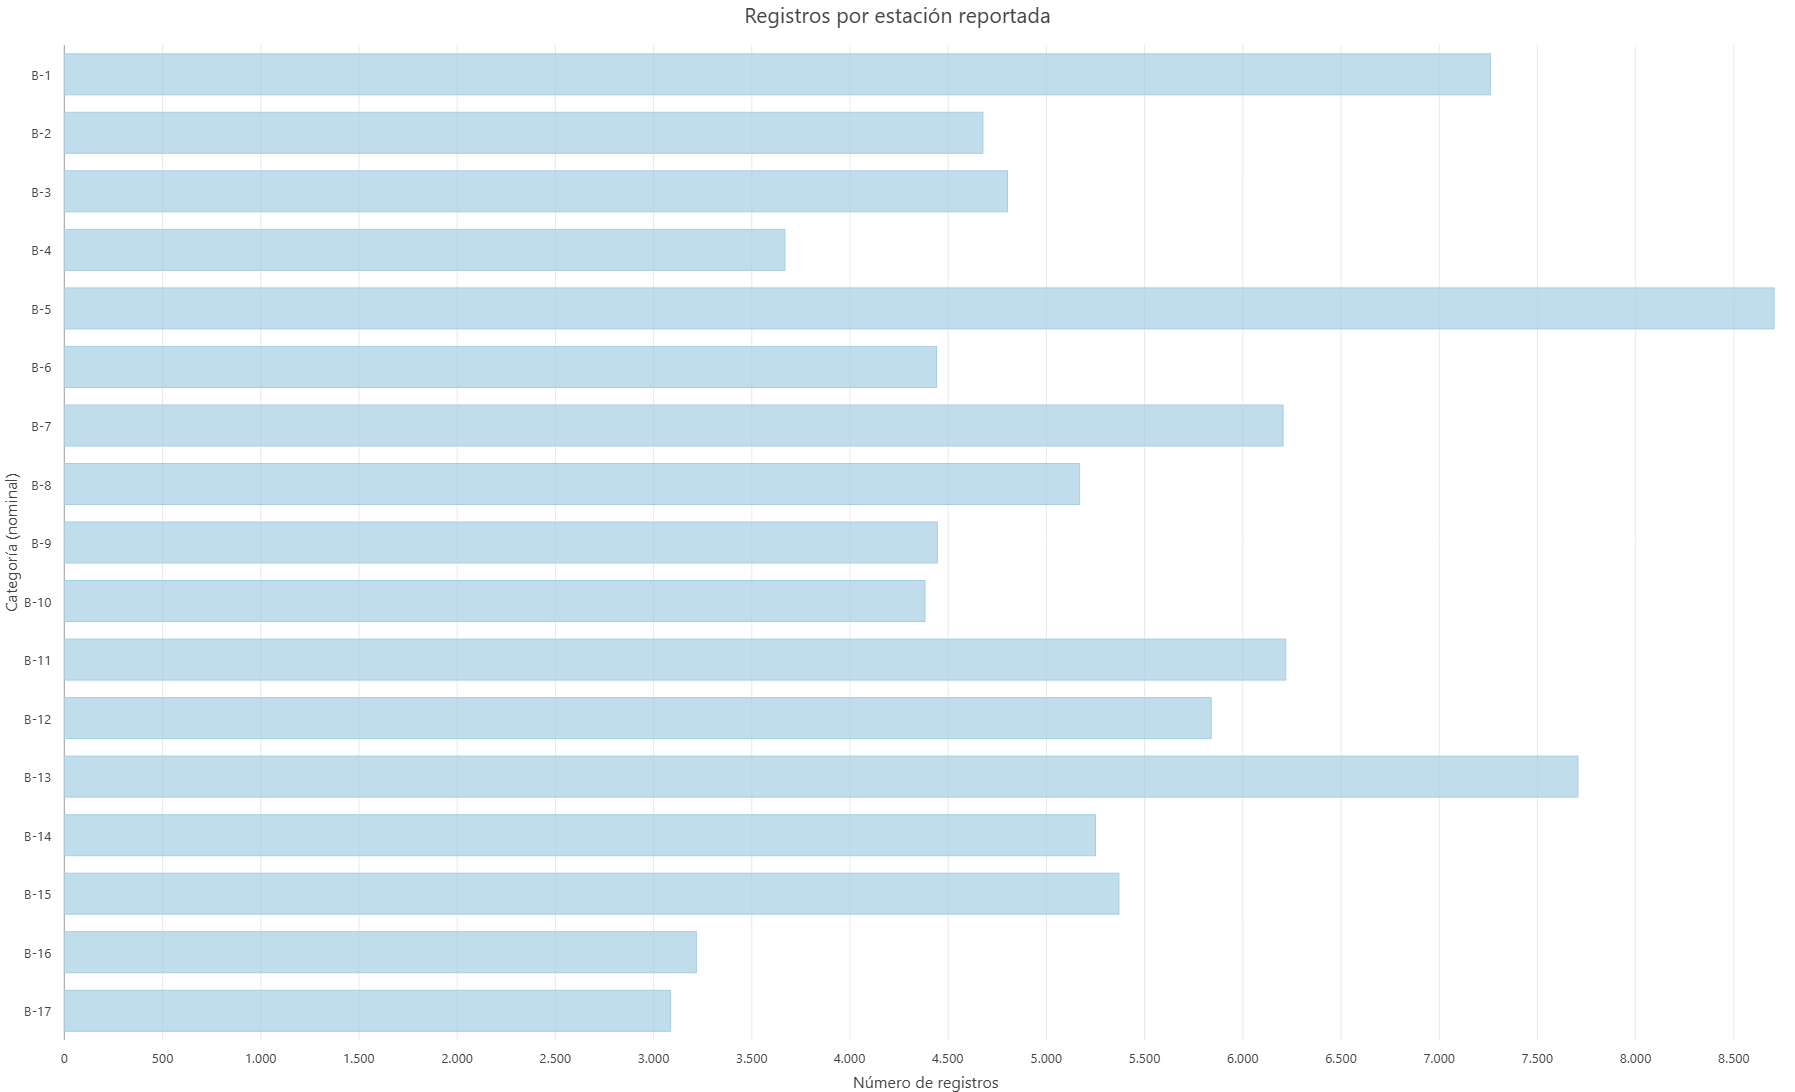

**Lectura:** longitud = filas por estación reportada. Diferencias de volumen no son tasas ni prueba de cobertura territorial.

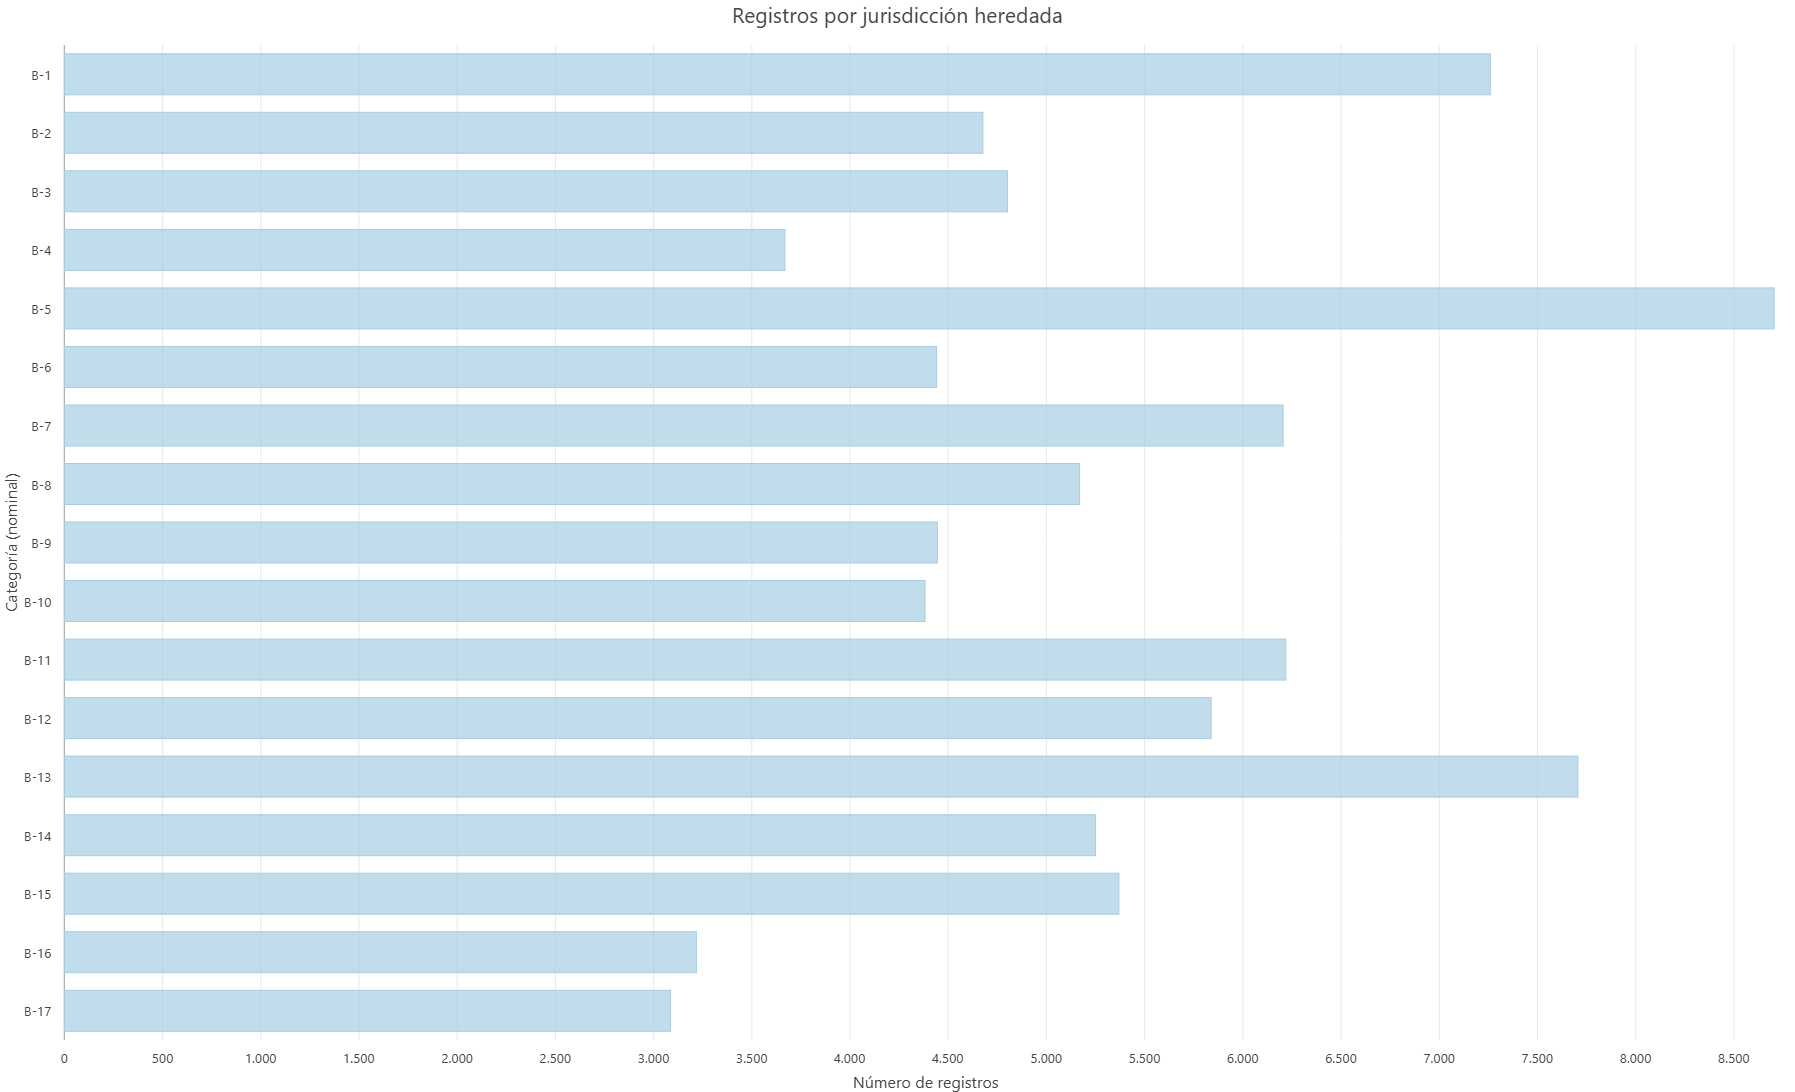

**Lectura:** la categoría procede de una unión espacial previa, no de la estación reportada. No se recalculó ni se validó como despacho.

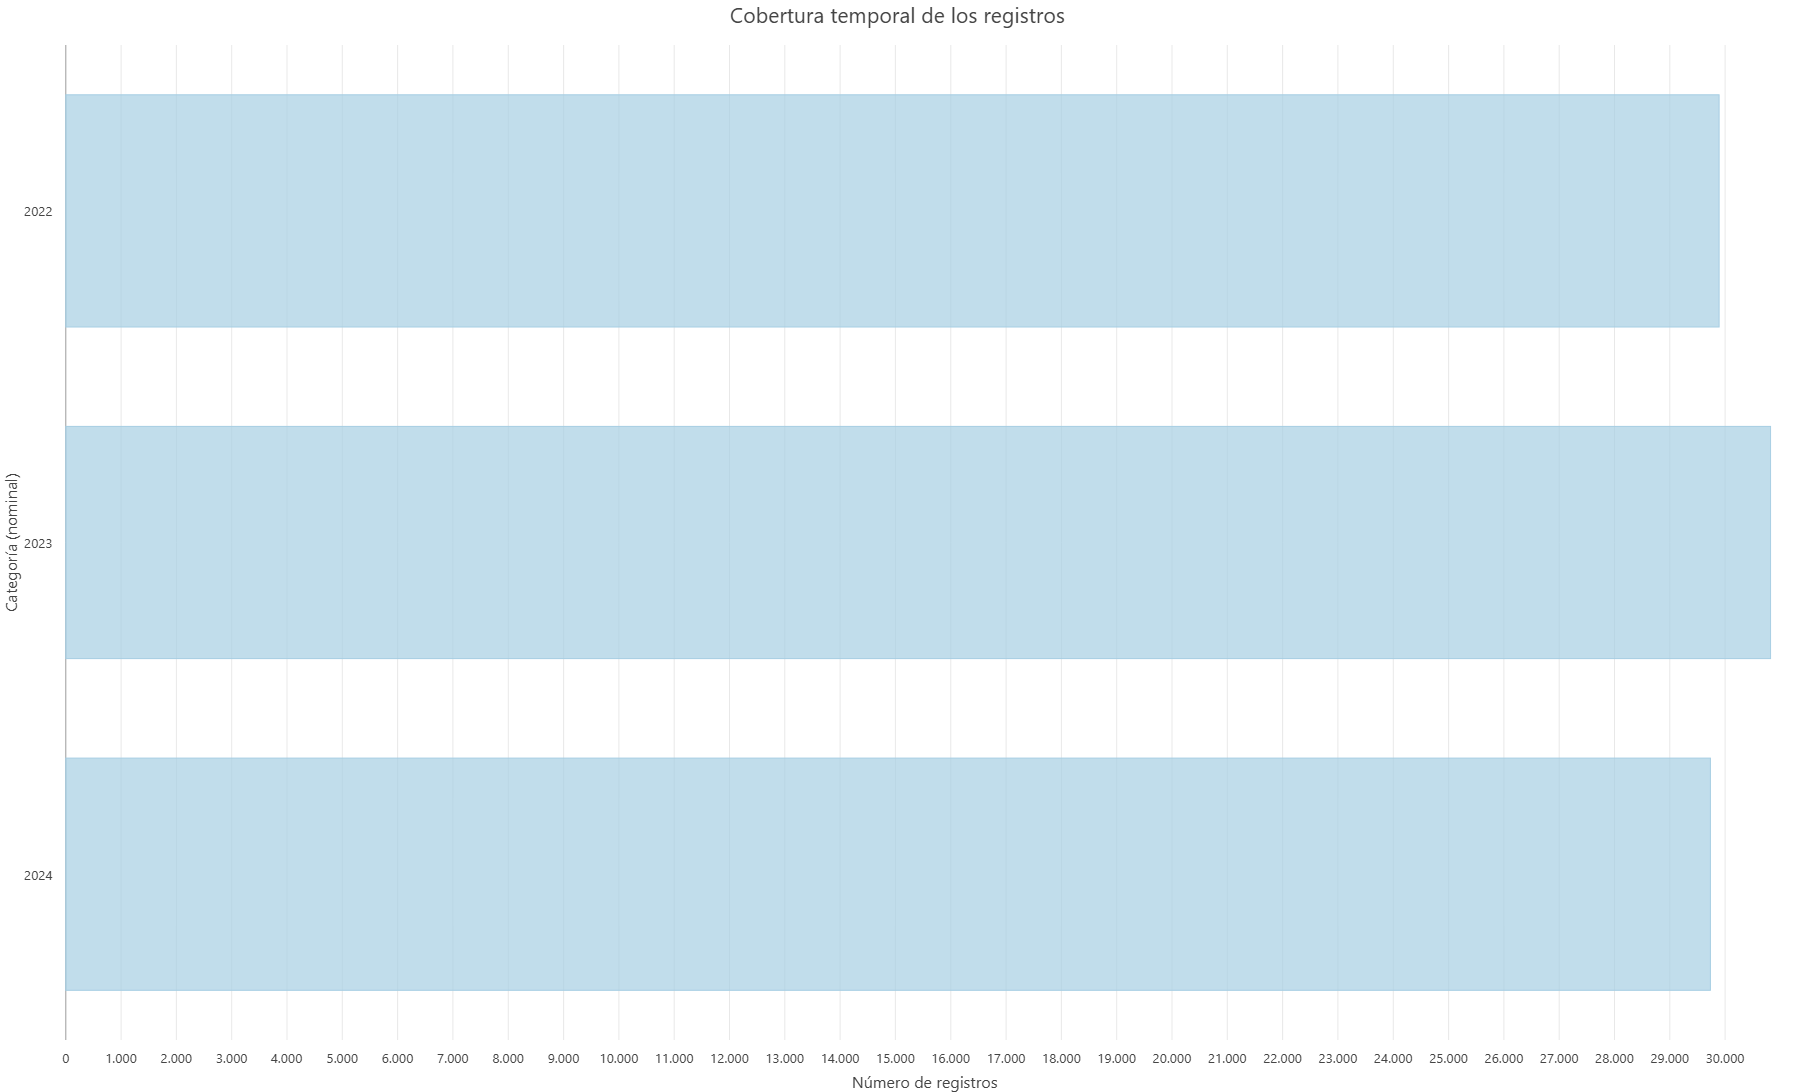

**Lectura:** compare conteos entre años, no promedios de fechas. Ausencia de registros no demostraría ausencia de incidentes.

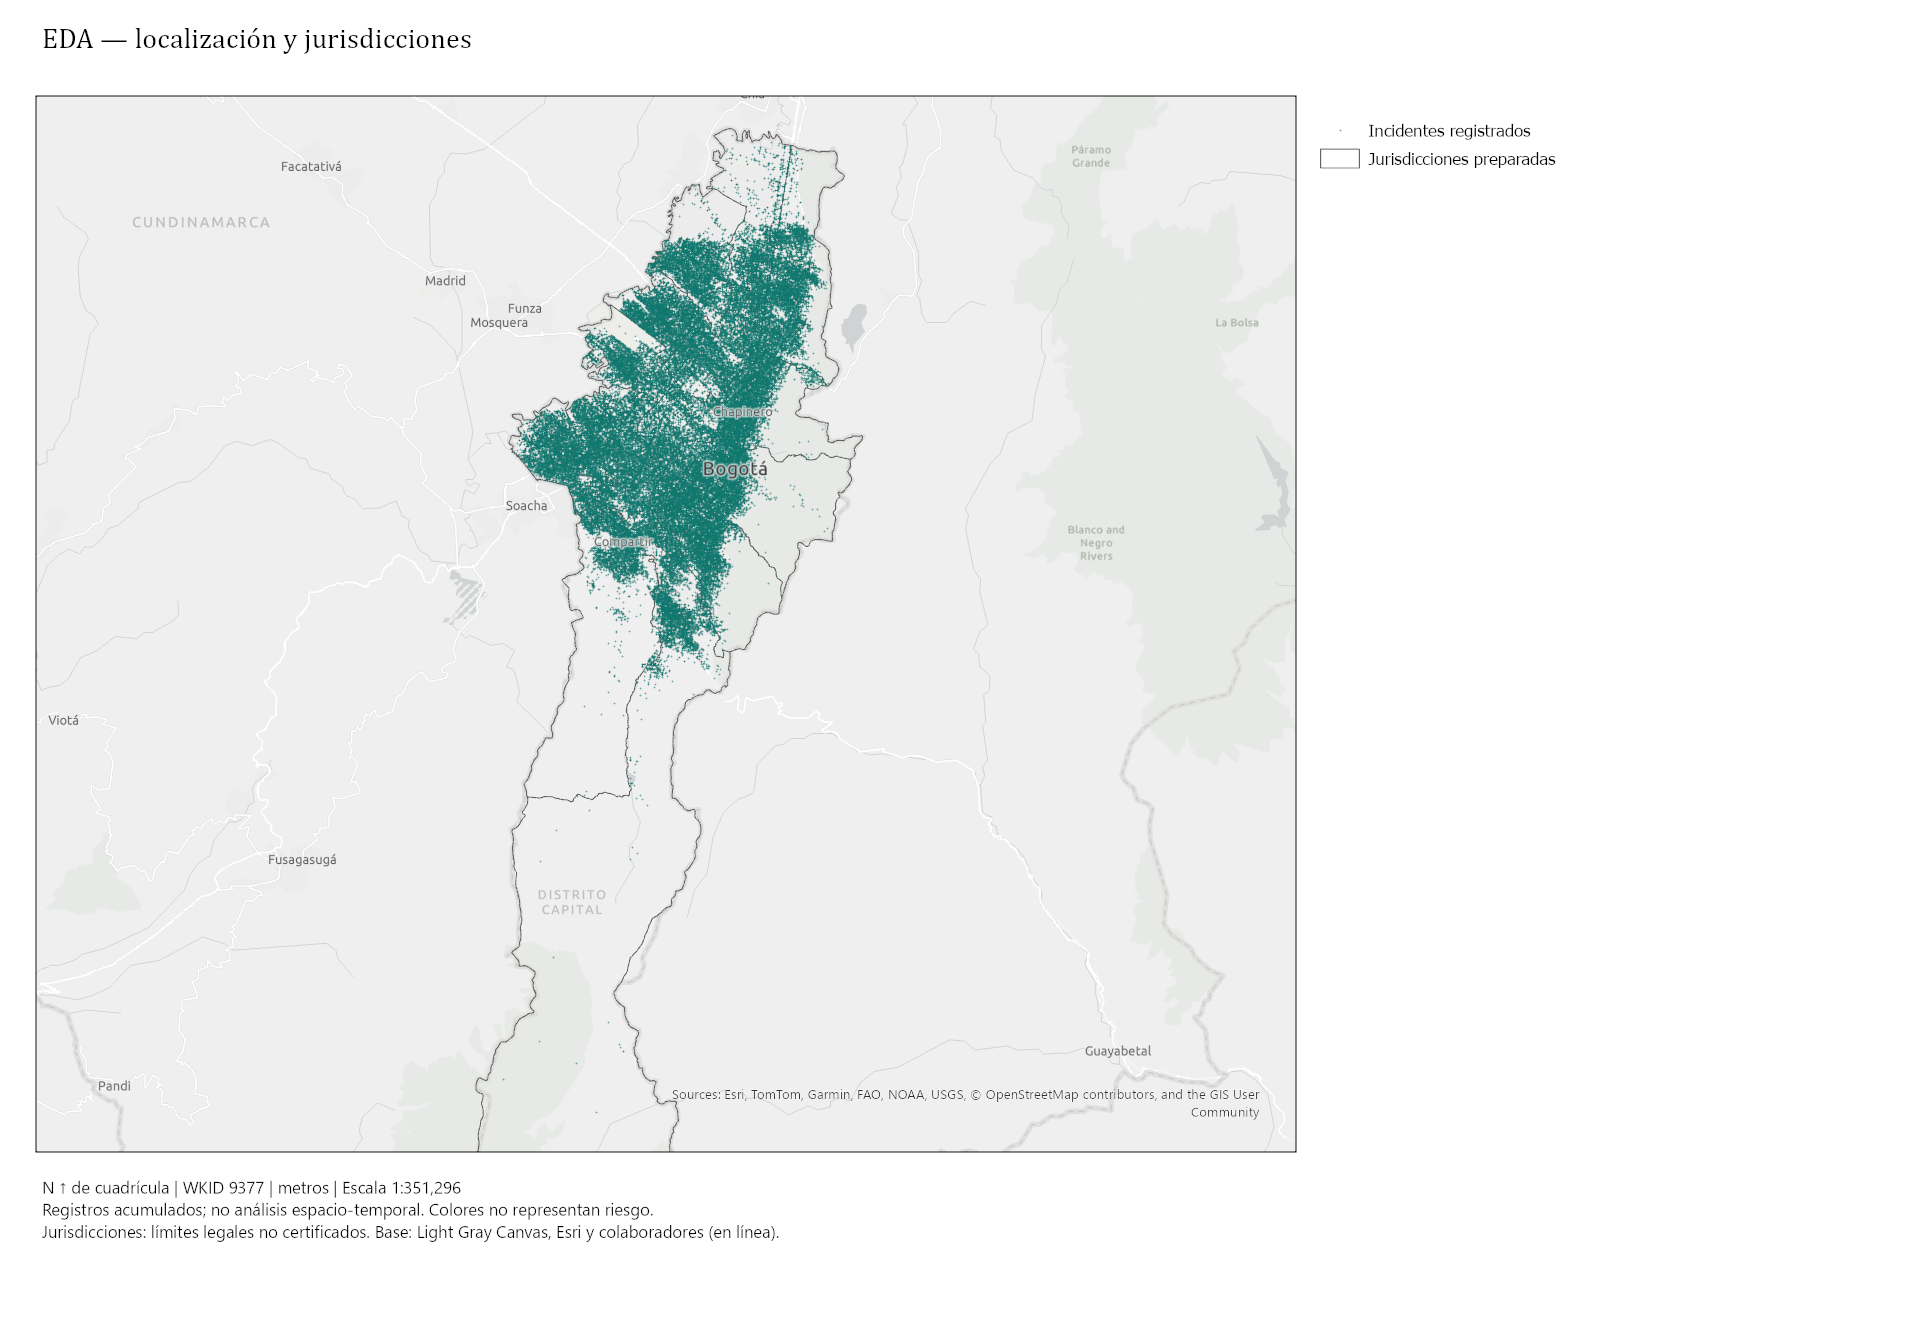

**Lectura:** puntos azules = registros; contornos = jurisdicciones preparadas. La superposición de puntos oculta multiplicidad; el perfil XY cuantifica esa repetición. No se proyectaron ni desplazaron puntos.

In [14]:
# EDA visible completa antes de llamar al primer algoritmo.
barras(PERFIL_DESPUES['estaciones'], 'arcgis_estaciones', 'Registros por estación reportada',
    '**Lectura:** longitud = filas por estación reportada. Diferencias de volumen no son tasas ni prueba de cobertura territorial.')
barras(PERFIL_DESPUES['jurisdiccion_heredada'], 'arcgis_jurisdicciones', 'Registros por jurisdicción heredada',
    '**Lectura:** la categoría procede de una unión espacial previa, no de la estación reportada. No se recalculó ni se validó como despacho.')
barras(PERFIL_DESPUES['anios'], 'arcgis_anios', 'Cobertura temporal de los registros',
    '**Lectura:** compare conteos entre años, no promedios de fechas. Ausencia de registros no demostraría ausencia de incidentes.')
mapa_png(PUNTOS, 'arcgis_mapa_entrada', 'EDA — localización y jurisdicciones',
    '**Lectura:** puntos azules = registros; contornos = jurisdicciones preparadas. La superposición de puntos oculta multiplicidad; el perfil XY cuantifica esa repetición. No se proyectaron ni desplazaron puntos.')

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** Las barras cuentan 29 890 registros en 2022, 30 821 en 2023 y 29 732 en 2024. El mapa posiciona filas, no tiempos de respuesta. Conclusión: cambian conteos registrados; exposición y cobertura podrían cambiar también. ¿Por qué la barra mayor no prueba mayor riesgo?

## 3. DBSCAN: vecindad fija, mínimo 100 y 350 m
DBSCAN conecta regiones densas mediante vecindades de 350 m; el mínimo incluye el punto evaluado. Un punto frontera puede pertenecer sin reunir por sí solo el mínimo. Analogía: una cadena de pequeños círculos solapados puede conectar lugares alejados; el círculo es la vecindad, **no** el radio máximo del grupo. La analogía no representa tiempos de viaje ni calles.

En un CRS métrico proyectado, los centros medios se calculan como promedios de X e Y por grupo, sin pesos adicionales. Primero identificamos todos los grupos y ruido (`CLUSTER_ID=-1`); después seleccionamos los asignados. Se espera preservar cada fila de entrada y obtener un número de grupos no fijado de antemano.

Esri, Pro 3.6, [Density-based Clustering, Parameters/Outputs](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/densitybasedclustering.htm) y [How Density-based Clustering works, Search Distance/Outputs](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-density-based-clustering-works.htm), consulta verificada 2026-09-15.

In [15]:
# Resumen nominal: nunca contar el ruido como un grupo ni comparar números entre métodos.
def etiquetas(entidad):
    with arcpy.da.SearchCursor(entidad, ['SOURCE_ID','CLUSTER_ID']) as cursor:
        frame = pd.DataFrame(list(cursor), columns=['SOURCE_ID','CLUSTER_ID'])
    with arcpy.da.SearchCursor(PUNTOS, ['OID@']) as cursor:
        esperados = {row[0] for row in cursor}
    if frame.SOURCE_ID.isna().any() or not frame.SOURCE_ID.is_unique or set(frame.SOURCE_ID) != esperados:
        raise RuntimeError('El modelo no conserva todas las claves técnicas de la copia.')
    if frame.CLUSTER_ID.isna().any():
        raise RuntimeError('Etiquetas nulas no esperadas.')
    counts = Counter(int(v) for v in frame.CLUSTER_ID)
    grupos = {k:v for k,v in counts.items() if k != -1}
    resumen = {'filas': len(frame), 'clusters': len(grupos), 'ruido': counts.get(-1,0),
        'porcentaje_ruido': 100*counts.get(-1,0)/len(frame), 'mayor_cluster': max(grupos.values(), default=0),
        'conteos': dict(sorted(counts.items()))}
    return frame, resumen
DBSCAN = str(GDB / 'IncidentesBomberosDBSCAN')
medir('DBSCAN', arcpy.stats.DensityBasedClustering, PUNTOS, DBSCAN, 'DBSCAN', 100, '350 Meters')
DB, METRICAS['DBSCAN'] = etiquetas(DBSCAN)
display(METRICAS['DBSCAN'])

{'filas': 90443,
 'clusters': 20,
 'ruido': 13384,
 'porcentaje_ruido': 14.798270734053492,
 'mayor_cluster': 67478,
 'conteos': {-1: 13384,
  1: 67478,
  2: 579,
  3: 2335,
  4: 459,
  5: 1175,
  6: 338,
  7: 956,
  8: 2175,
  9: 232,
  10: 81,
  11: 230,
  12: 132,
  13: 161,
  14: 182,
  15: 99,
  16: 66,
  17: 107,
  18: 96,
  19: 102,
  20: 76}}

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** DBSCAN conservó 90 443 filas: 20 grupos, 13 384 ruidos (14.798271 %) y grupo mayor de 67 478. IDs nominales; −1 no cuenta como grupo. La vecindad de 350 m conecta una estructura dominante, no limita su diámetro ni define cobertura de estaciones. ¿Puede una cadena superar 350 m?

### Selección sin ruido y centro medio por grupo
Se seleccionan `CLUSTER_ID <> -1`; no se borran los puntos ruidosos del resultado DBSCAN. MeanCenter agrupa mediante Case_Field, no mediante una selección manual de cada clase. Un centro representa la media de las posiciones de los registros; no pondera severidad, habitantes ni accesibilidad.

Referencia exacta de implementación: **Esri, ayuda Python instalada ArcGIS Pro 3.6.2**, `arcpy.stats.MeanCenter`, secciones Input_Feature_Class/Case_Field/Output_Feature_Class, consultada con `inspect.getdoc` el 2026-09-15. No se atribuye consulta web nueva a esta referencia local.

In [16]:
# La selección mantiene la clase completa intacta; solo limita las herramientas posteriores.
asignados = arcpy.management.MakeFeatureLayer(DBSCAN, 'dbscan_asignados').getOutput(0)
medir('Seleccion_sin_ruido', arcpy.management.SelectLayerByAttribute, asignados, 'NEW_SELECTION', 'CLUSTER_ID <> -1')
CENTROS = str(GDB / 'CentrosMediosDBSCAN')
medir('MeanCenter', arcpy.stats.MeanCenter, asignados, CENTROS, Case_Field='CLUSTER_ID')
N_CENTROS = int(arcpy.management.GetCount(CENTROS)[0])
if N_CENTROS != METRICAS['DBSCAN']['clusters']:
    raise RuntimeError('No hay exactamente un centro medio por grupo.')
print('Centros medios:', N_CENTROS, '; puntos seleccionados:', int(arcpy.management.GetCount(asignados)[0]))

Centros medios: 20 ; puntos seleccionados: 77059


**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** 77 059 registros asignados dieron 20 centros promediando X e Y. Es posición media, no medoid (punto observado) ni estación óptima; puede caer fuera de una forma no convexa. ¿Se incorporó severidad o red vial? No.

### Identity: coincidencia geométrica, no asignación operativa
Identity conserva centros sin intersección y transfiere atributos jurisdiccionales cuando coincide la geometría. Se usa `NO_FID`, tal como exige el procedimiento: sin IDs de entidad heredados. No se cambia la tolerancia XY. Un centro sobre frontera o superposición puede tener varias coincidencias; se registran todas, sin escoger la primera ni la más cercana.

Referencia: **Esri, ayuda Python instalada Pro 3.6.2**, `arcpy.analysis.Identity`, join_attributes/cluster_tolerance, consultada el 2026-09-15. NO_FID puede producir textos vacíos o ceros cuando no hay intersección: no confundirlos con un código jurisdiccional válido.

In [17]:
# Superponer exclusivamente con la jurisdicción preparada y comprobada, de solo lectura.
IDENTIDAD = str(GDB / 'CentrosIdentidadDBSCAN')
medir('Identity', arcpy.analysis.Identity, CENTROS, str(PREPARED_JURIS), IDENTIDAD, 'NO_FID')
with arcpy.da.SearchCursor(IDENTIDAD, ['CLUSTER_ID','ESTACION','NOMBRE_CORTO_EST']) as cursor:
    identidad = pd.DataFrame(list(cursor), columns=['CLUSTER_ID','ESTACION','NOMBRE_CORTO_EST'])
filas_por_centro = identidad.groupby('CLUSTER_ID').size()
SIN_JURIS = sorted(int(v) for v in identidad.loc[identidad.ESTACION.isna() | identidad.ESTACION.eq(''), 'CLUSTER_ID'].unique())
MULTIPLES = {int(k):int(v) for k,v in filas_por_centro.items() if v > 1}
display(identidad)
print('Centros sin jurisdicción:', SIN_JURIS, '; filas múltiples por centro:', MULTIPLES)

Centros sin jurisdicción: [] ; filas múltiples por centro: {}


,CLUSTER_ID,ESTACION,NOMBRE_CORTO_EST
0,9,B-10,Marichuela
1,8,B-10,Marichuela
2,7,B-10,Marichuela
3,16,B-11,La Candelaria
4,10,B-8,Bosa
5,13,B-4,Puente Aranda
6,15,B-4,Puente Aranda
7,19,B-4,Puente Aranda
8,14,B-4,Puente Aranda
9,20,B-4,Puente Aranda


**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** 20 centros sin no asignados ni coincidencias múltiples en esta corrida. Una frontera compartida puede producir varias filas y repetir conteos tras unirlos. Conclusión: no se observó esa ambigüedad; no certifica jurisdicción legal. ¿Qué haría con dos coincidencias? Informarlas, no escoger una.

### Fronteras y tolerancia
Además de las filas de Identity, se comprueba si un centro toca una frontera o está a una distancia menor o igual a la tolerancia XY declarada del CRS. Proximidad a tolerancia **no significa** pertenencia forzada. Se informa por separado; la geometría no certifica límites legales.

Referencia: **Esri, ayuda Python instalada Pro 3.6.2**, `Geometry.touches`, `Geometry.boundary`, `Geometry.distanceTo`, consultada el 2026-09-15: distanceTo requiere la misma proyección y devuelve distancia mínima, cero si se intersectan.

In [18]:
# Diagnóstico de todos los centros contra los 17 polígonos, sin editar ni asignar por cercanía.
with arcpy.da.SearchCursor(str(PREPARED_JURIS), ['ESTACION','SHAPE@']) as cursor:
    poligonos = [(codigo, geom, geom.boundary()) for codigo, geom in cursor]
FRONTERAS = []
with arcpy.da.SearchCursor(CENTROS, ['CLUSTER_ID','SHAPE@']) as cursor:
    for cluster, punto in cursor:
        for codigo, poligono, borde in poligonos:
            distancia = punto.distanceTo(borde)
            if punto.touches(poligono) or distancia <= sr.XYTolerance:
                FRONTERAS.append({'cluster': int(cluster), 'estacion': codigo, 'distancia_m': distancia, 'toca': punto.touches(poligono)})
DIAGNOSTICO_CENTROS = {'centros': N_CENTROS, 'filas_identity': len(identidad), 'sin_jurisdiccion': SIN_JURIS,
    'multiples': MULTIPLES, 'fronteras': FRONTERAS, 'tolerancia_xy_m': sr.XYTolerance}
display(DIAGNOSTICO_CENTROS)

{'centros': 20,
 'filas_identity': 20,
 'sin_jurisdiccion': [],
 'multiples': {},
 'fronteras': [],
 'tolerancia_xy_m': 0.001}

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** Con tolerancia XY=0.001 m: 0 contactos/cercanías de frontera y 20 filas Identity para 20 centros. La prueba usa geometría preparada, no precisión legal de 1 mm. ¿Cero hallazgos elimina incertidumbre del límite original?

### Statistics → AddJoin → CopyFeatures
El COUNT se calcula **sobre los incidentes seleccionados sin ruido**, con campo estadístico y campo de caso `CLUSTER_ID`. No se cuentan centros: de hacerlo, se obtendría uno por grupo en lugar de su población. COUNT excluye nulos; aquí se verificó que no existen etiquetas nulas.

La tabla tiene una fila por grupo. AddJoin enlaza esa tabla con las filas de Identity por `CLUSTER_ID`; CopyFeatures materializa el resultado. Si Identity repite un centro por varias jurisdicciones, su conteo aparecerá varias veces: no sumar esas filas como si fueran grupos distintos.

Referencia: **Esri, ayuda Python instalada Pro 3.6.2**, `arcpy.analysis.Statistics` (statistics_fields/case_field) y `arcpy.management.AddJoin` (join_type/index_join_fields/join_operation), consultada el 2026-09-15. Se conserva KEEP_ALL y no se añaden índices a entradas originales.

In [19]:
# Conteo de registros por grupo y unión explícita sin agregación jurisdiccional forzada.
CONTEOS = str(GDB / 'ConteosDBSCAN')
medir('Statistics_COUNT', arcpy.analysis.Statistics, asignados, CONTEOS, [['CLUSTER_ID','COUNT']], 'CLUSTER_ID')
with arcpy.da.SearchCursor(CONTEOS, ['CLUSTER_ID','COUNT_CLUSTER_ID']) as cursor:
    poblacion_grupos = {int(k): int(v) for k,v in cursor}
if poblacion_grupos != {int(k):int(v) for k,v in METRICAS['DBSCAN']['conteos'].items() if k != -1}:
    raise RuntimeError('COUNT no coincide con la población de cada grupo DBSCAN.')
centros_layer = arcpy.management.MakeFeatureLayer(IDENTIDAD, 'centros_para_union').getOutput(0)
medir('AddJoin', arcpy.management.AddJoin, centros_layer, 'CLUSTER_ID', CONTEOS, 'CLUSTER_ID', 'KEEP_ALL')
CENTROS_FINALES = str(GDB / 'IncidentesBomberosCentrosGruposDB')
medir('CopyFeatures_centros', arcpy.management.CopyFeatures, centros_layer, CENTROS_FINALES)
DIAGNOSTICO_CENTROS['filas_finales'] = int(arcpy.management.GetCount(CENTROS_FINALES)[0])
if DIAGNOSTICO_CENTROS['filas_finales'] != len(identidad):
    raise RuntimeError('La unión alteró la cardinalidad esperada de Identity.')
display(pd.DataFrame(sorted(poblacion_grupos.items()), columns=['Grupo','COUNT_CLUSTER_ID']))
print('Suma de COUNT sin ruido:', sum(poblacion_grupos.values()))
materializados = ['CentrosIdentidadDBSCAN_CLUSTER_ID', 'ConteosDBSCAN_COUNT_CLUSTER_ID']
with arcpy.da.SearchCursor(CENTROS_FINALES, materializados) as cursor:
    if any(poblacion_grupos[int(k)] != int(n) for k,n in cursor):
        raise RuntimeError('La copia materializada no conserva COUNT por grupo.')
DIAGNOSTICO_CENTROS['grupos_menores_100'] = {k:n for k,n in poblacion_grupos.items() if n < 100}
print('Tamaños finales menores de 100 (no reclasificados):', DIAGNOSTICO_CENTROS['grupos_menores_100'])

Suma de COUNT sin ruido: 77059
Tamaños finales menores de 100 (no reclasificados): {10: 81, 15: 99, 16: 66, 18: 96, 20: 76}


,Grupo,COUNT_CLUSTER_ID
0,1,67478
1,2,579
2,3,2335
3,4,459
4,5,1175
5,6,338
6,7,956
7,8,2175
8,9,232
9,10,81


**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** Suma COUNT sin ruido=77 059; grupos finales 10/15/16/18/20 contienen 81/99/66/96/76 filas, sin reclasificar para forzar 100. COUNT cuenta asignados, no centros ni riesgo. Una coincidencia múltiple puede repetirlo en la unión. ¿Qué suma verificaría antes de agregar por jurisdicción?

### Resultados DBSCAN
El mapa distingue puntos, ruido y centros medios. Las barras incluyen el ruido como categoría explícita para conservar el denominador completo, aunque no es un grupo. La tabla anterior excluye ruido únicamente porque calcula población de grupos. Contraste tamaño del grupo dominante con los pequeños: la densidad conectada puede formar extensiones grandes aun con vecindad de 350 m.

**Observación comprobada de la ejecución vigente `ejecucion_20260915T220908_d62e311d` (también observada en el intento anterior preservado):** los grupos 10, 15, 16, 18 y 20 contienen respectivamente 81, 99, 66, 96 y 76 filas, aunque el parámetro suministrado fue 100. Statistics COUNT y el conteo independiente de CLUSTER_ID coinciden; la unión materializada conserva esos valores. No se afirma que todos los grupos finales superen 100 ni se borran o fusionan para ajustar el resultado al enunciado. La causa específica de este comportamiento de la implementación queda sin diagnosticar; no atribuirla sin evidencia a duplicados, fronteras o calidad de datos. La operación requerida se ejecutó con su parámetro autorizado; convertir el resultado en un criterio operativo exige resolver esta limitación.

**Lectura cartográfica observada:** domina el grupo 1 (67 478 filas), acompañado de grupos pequeños y ruido periférico. Los 20 centros coinciden con una única jurisdicción cada uno: no hubo centros sin jurisdicción, coincidencias múltiples ni proximidad a frontera dentro de 0.001 m. Son relaciones geométricas de estos centros, no una asignación operativa de todos sus incidentes.

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


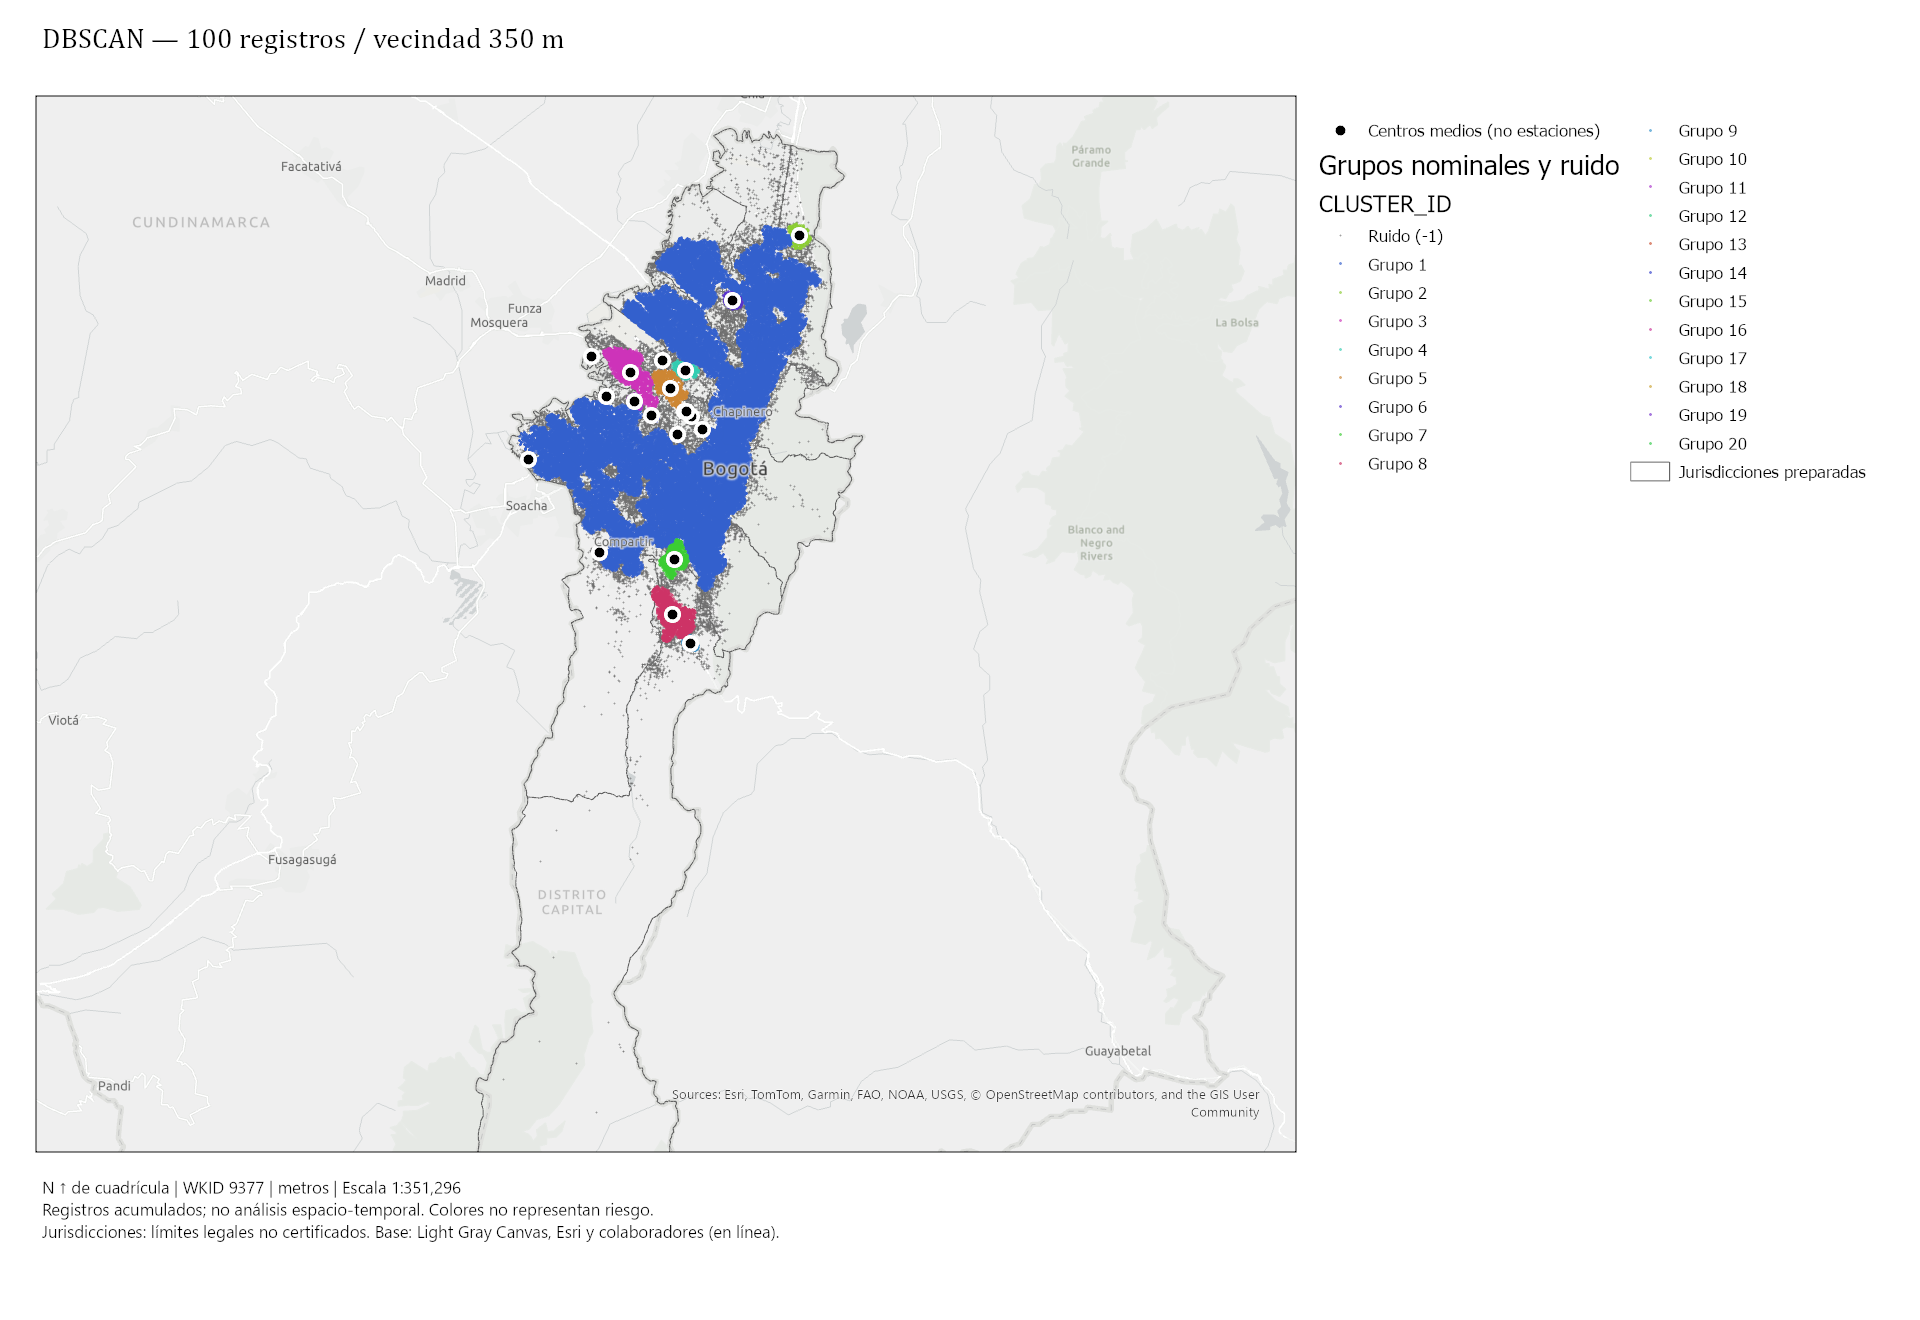

**Lectura:** colores = grupos, gris = ruido, puntos negros = centros medios. Un centro resume posiciones, no delimita cobertura de atención.

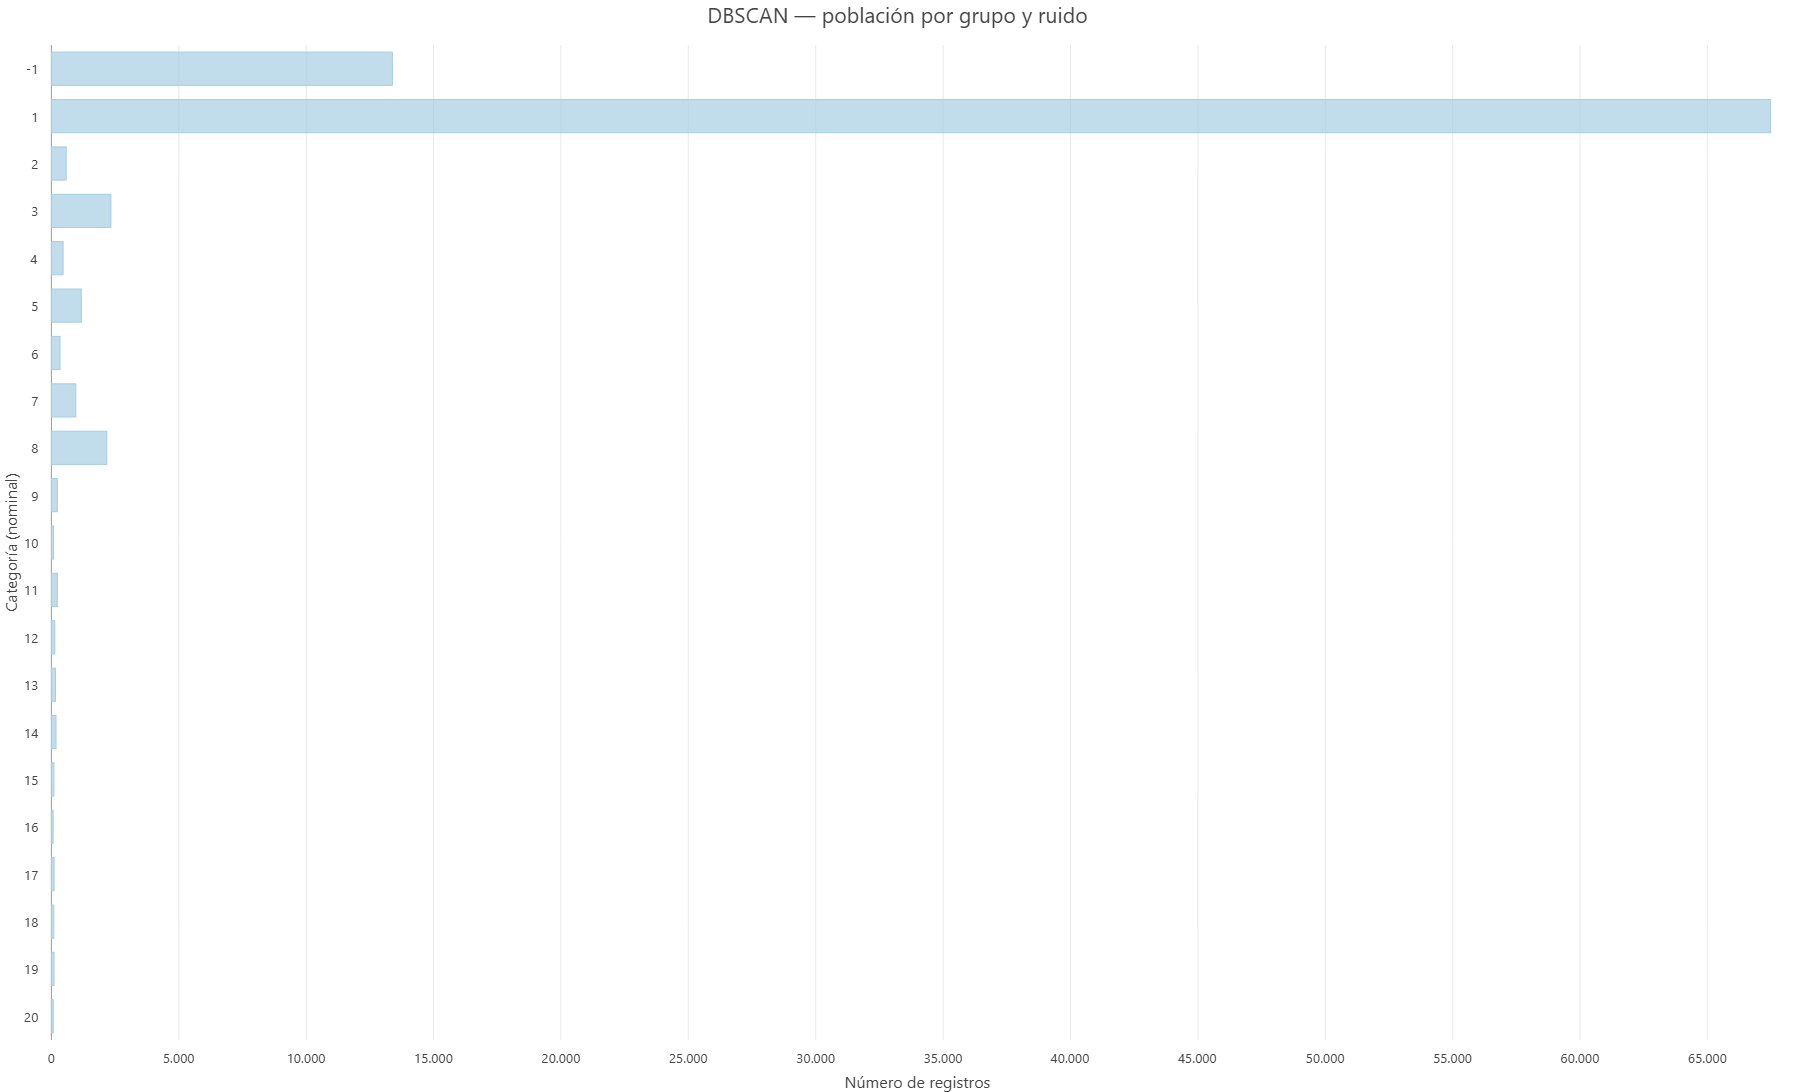

**Lectura:** -1 es ruido, no un grupo adicional. El eje de cantidad cuenta filas; grupos conectados pueden extenderse más de 350 m.

**Observado:** 20 grupos, 13,384 registros ruidosos y 67,478 registros con etiqueta 1. 20 centros, 0 sin jurisdicción y 0 con filas múltiples. Estos resultados no certifican despacho ni riesgo.

In [20]:
# Mostrar resultados calculados; no reproducir cifras impresas como si fueran observaciones.
mapa_png(DBSCAN, 'arcgis_mapa_dbscan', 'DBSCAN — 100 registros / vecindad 350 m',
    '**Lectura:** colores = grupos, gris = ruido, puntos negros = centros medios. Un centro resume posiciones, no delimita cobertura de atención.', True, CENTROS_FINALES)
barras(METRICAS['DBSCAN']['conteos'], 'arcgis_poblacion_dbscan', 'DBSCAN — población por grupo y ruido',
    '**Lectura:** -1 es ruido, no un grupo adicional. El eje de cantidad cuenta filas; grupos conectados pueden extenderse más de 350 m.')
display(Markdown(f"**Observado:** {METRICAS['DBSCAN']['clusters']} grupos, {METRICAS['DBSCAN']['ruido']:,} registros ruidosos y {METRICAS['DBSCAN']['conteos'].get(1,0):,} registros con etiqueta 1. {N_CENTROS} centros, {len(SIN_JURIS)} sin jurisdicción y {len(MULTIPLES)} con filas múltiples. Estos resultados no certifican despacho ni riesgo."))

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** El mapa/barras muestran 20 grupos y 13 384 ruidos; 67 478 registros en el mayor grupo comprimen las barras pequeñas. Conclusión: domina una agrupación, no una estación óptima. ¿Igual color entre métodos identifica iguales miembros?

## 4. HDBSCAN: densidades variables, mínimo 100
HDBSCAN construye una jerarquía de agrupaciones y extrae grupos estables. Analogía: observar islas a distintos niveles de agua ayuda a entender qué regiones persisten; el nivel representa un umbral de densidad, no elevación real. El resultado plano no muestra toda la jerarquía.

Se pasa mínimo 100 sin imponer una distancia fija de 350 m. Los mismos puntos permiten comparar cobertura y ruido con DBSCAN. PROB describe pertenencia al grupo asignado: no es un valor p, probabilidad de un incidente futuro ni certeza de una frontera. Para interpretar el histograma se excluyen únicamente de ese gráfico los registros etiquetados como ruido; la clase de salida completa se conserva.

Esri, Pro 3.6, Density-based Clustering y How Density-based Clustering works, métodos/Outputs (enlaces de §3), consulta verificada 2026-09-15.

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


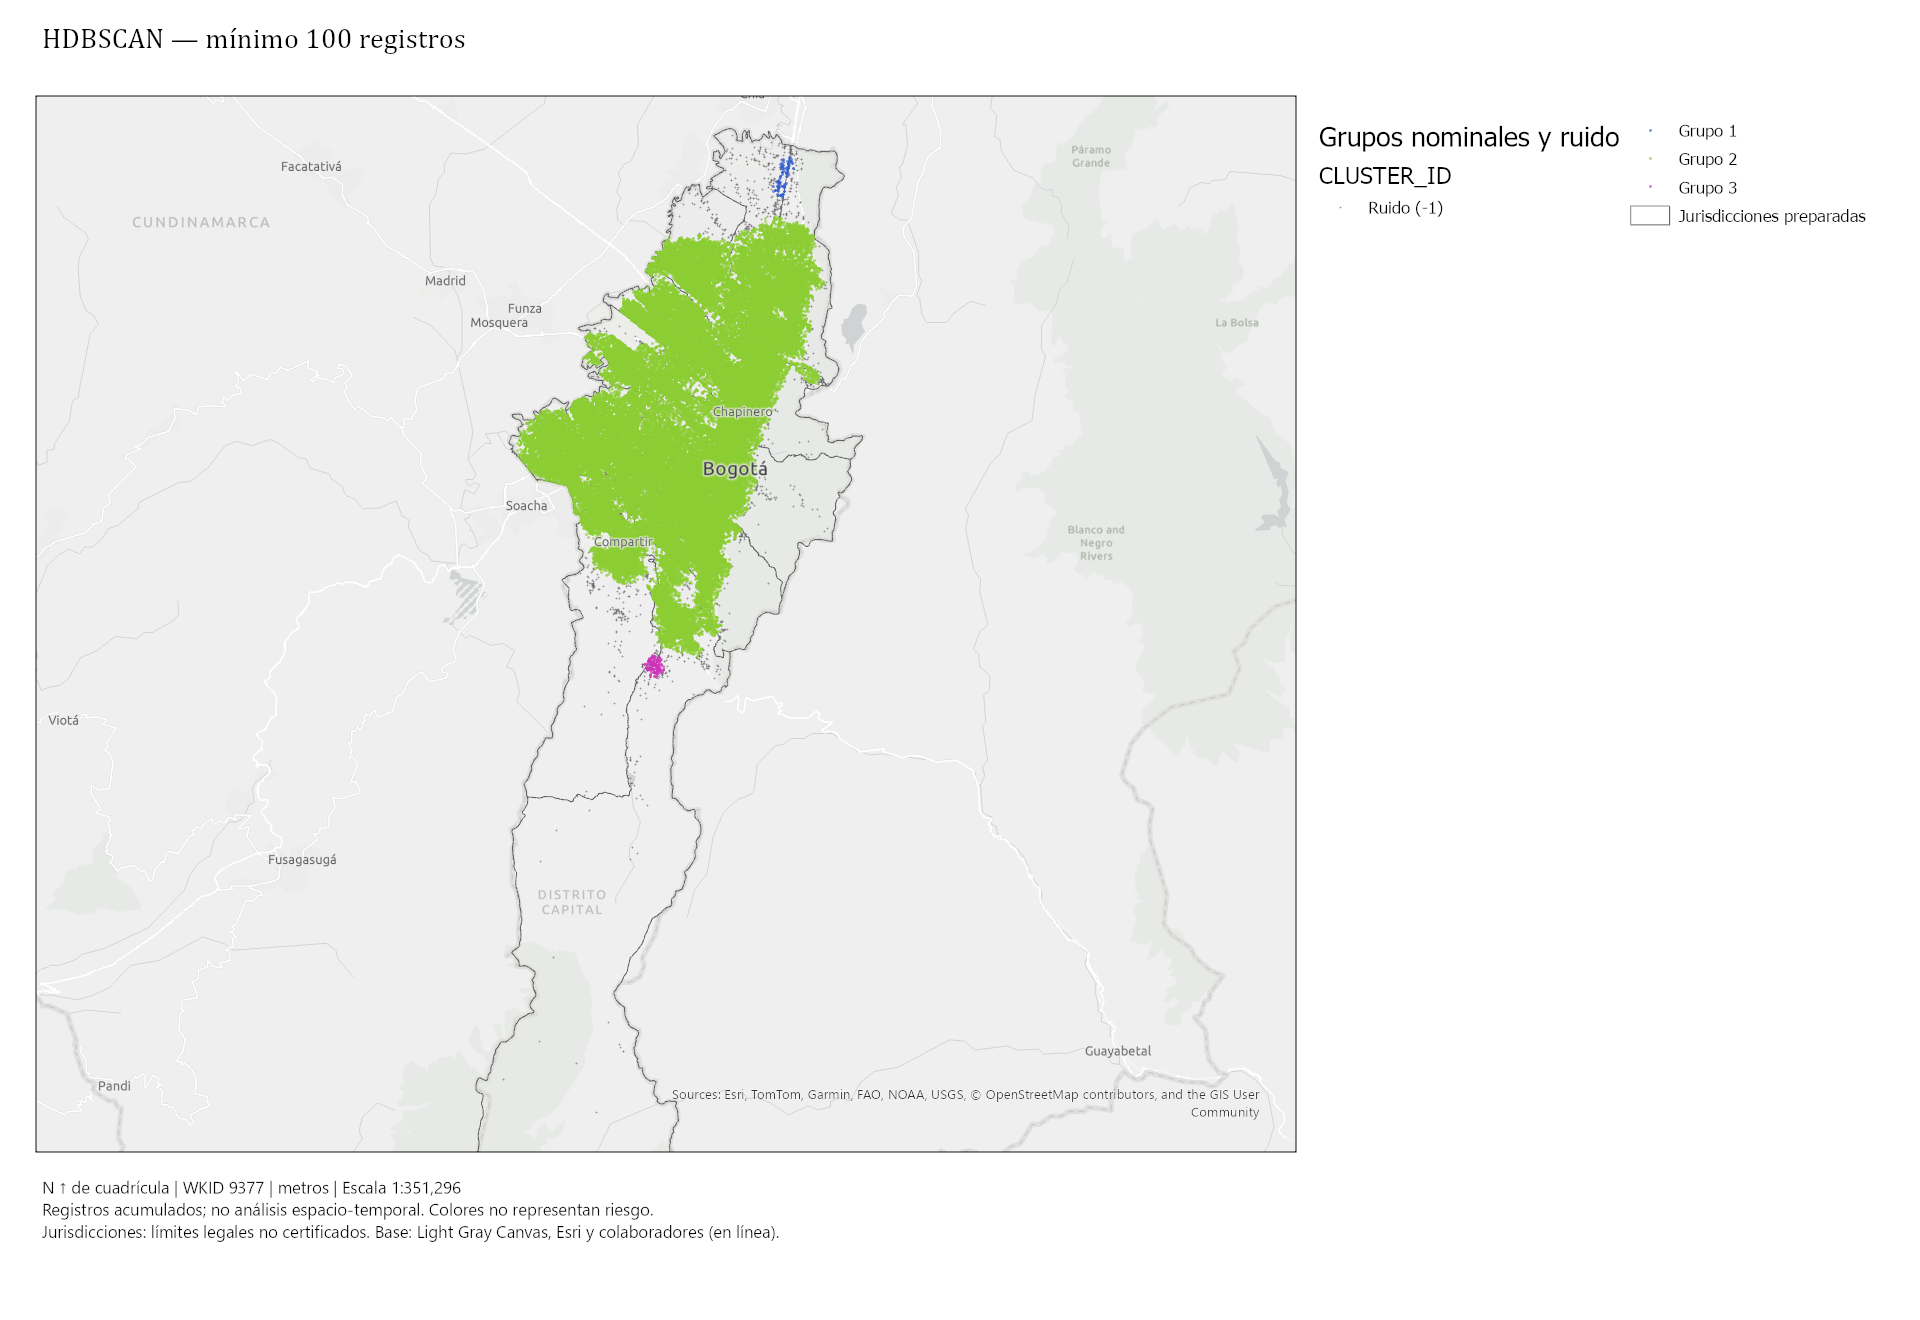

**Lectura:** compare continuidad espacial y ruido con DBSCAN a la misma extensión; un color o número igual no significa el mismo grupo.

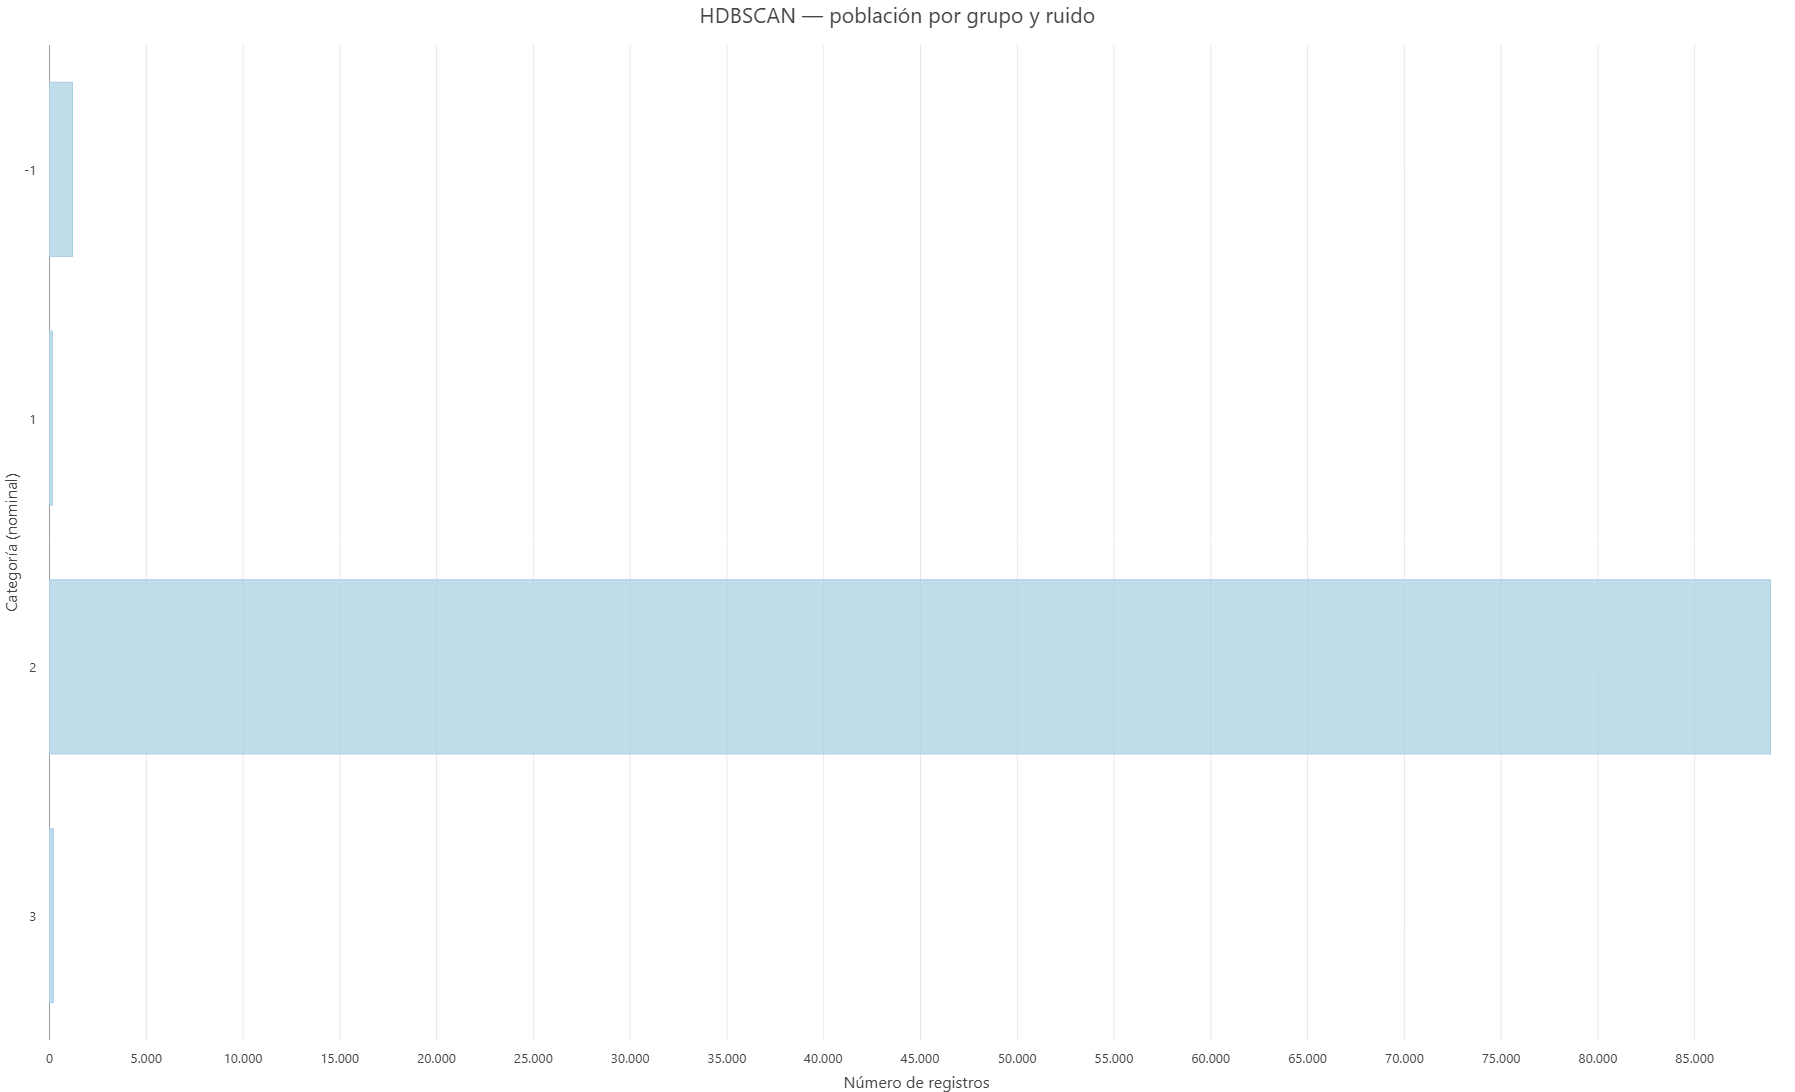

**Lectura:** menos ruido no demuestra un método mejor; puede reflejar una definición distinta de estructura persistente.

{'filas': 90443,
 'clusters': 3,
 'ruido': 1187,
 'porcentaje_ruido': 1.3124288225733334,
 'mayor_cluster': 88919,
 'conteos': {-1: 1187, 1: 146, 2: 88919, 3: 191}}

In [21]:
# HDBSCAN no recibe un epsilon fijo ni se fuerza a reproducir grupos históricos.
HDBSCAN = str(GDB / 'IncidentesBomberosHDBSCAN')
medir('HDBSCAN', arcpy.stats.DensityBasedClustering, PUNTOS, HDBSCAN, 'HDBSCAN', 100)
HD, METRICAS['HDBSCAN'] = etiquetas(HDBSCAN)
mapa_png(HDBSCAN, 'arcgis_mapa_hdbscan', 'HDBSCAN — mínimo 100 registros',
    '**Lectura:** compare continuidad espacial y ruido con DBSCAN a la misma extensión; un color o número igual no significa el mismo grupo.', True)
barras(METRICAS['HDBSCAN']['conteos'], 'arcgis_poblacion_hdbscan', 'HDBSCAN — población por grupo y ruido',
    '**Lectura:** menos ruido no demuestra un método mejor; puede reflejar una definición distinta de estructura persistente.')
display(METRICAS['HDBSCAN'])

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** HDBSCAN produjo 3 grupos, 1 187 ruidos (1.312429 %) y 88 919 filas en el grupo mayor. Menos ruido no acredita exactitud ni fronteras ciertas. ¿Puede una agrupación enorme ocultar estructura útil?

### Distribución de pertenencia y atipicidad
PROB y OUTLIER se leen para registros asignados; sus valores para ruido pueden carecer de la misma interpretación. El histograma representa frecuencia de filas por intervalo de valor, no evidencia de significancia estadística. Se conserva OUTLIER como contraste adicional y se informa el número de valores válidos; no se inventa un campo de estabilidad.

Esri, Pro 3.6, [Histogram, binCount/dataSource/exportToPNG](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/histogram.htm) y Density-based Clustering, Outputs, consulta verificada 2026-09-15.

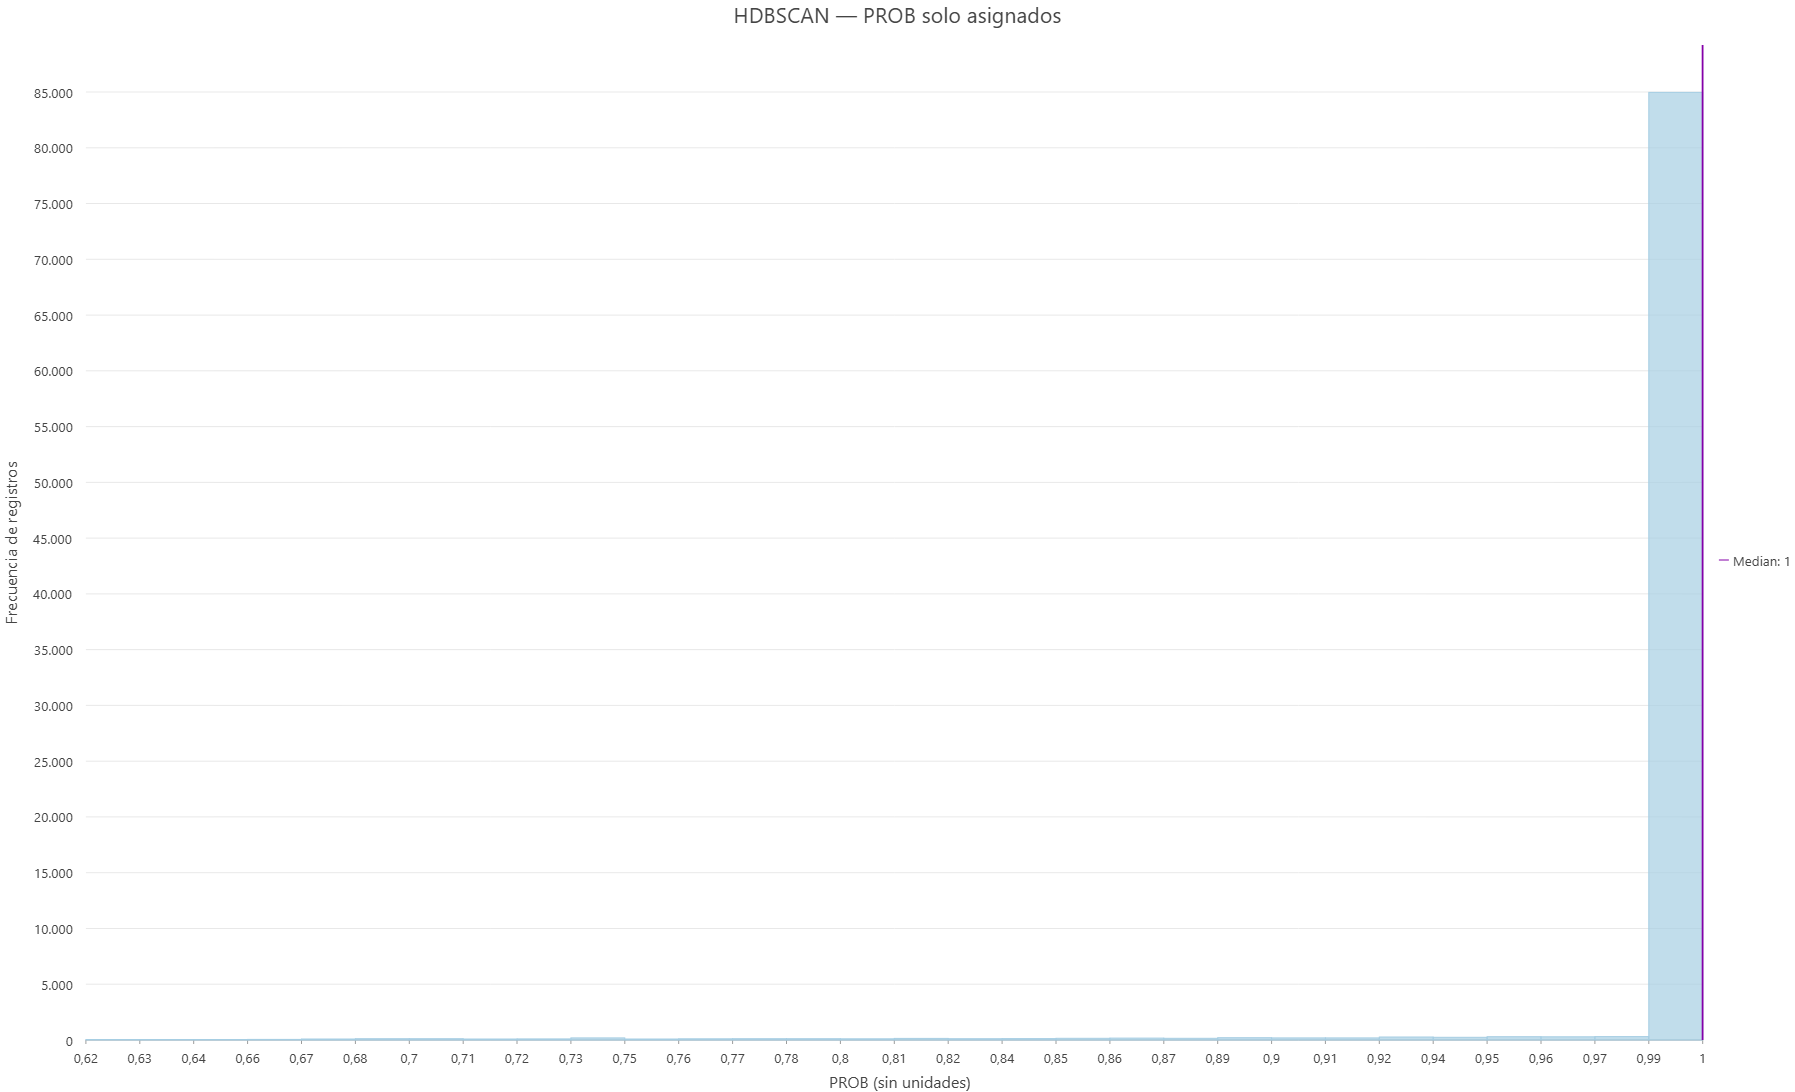

**Lectura:** frecuencia por intervalo entre asignados. Valores altos de PROB no son significancia; OUTLIER describe atipicidad respecto de la estructura del método.

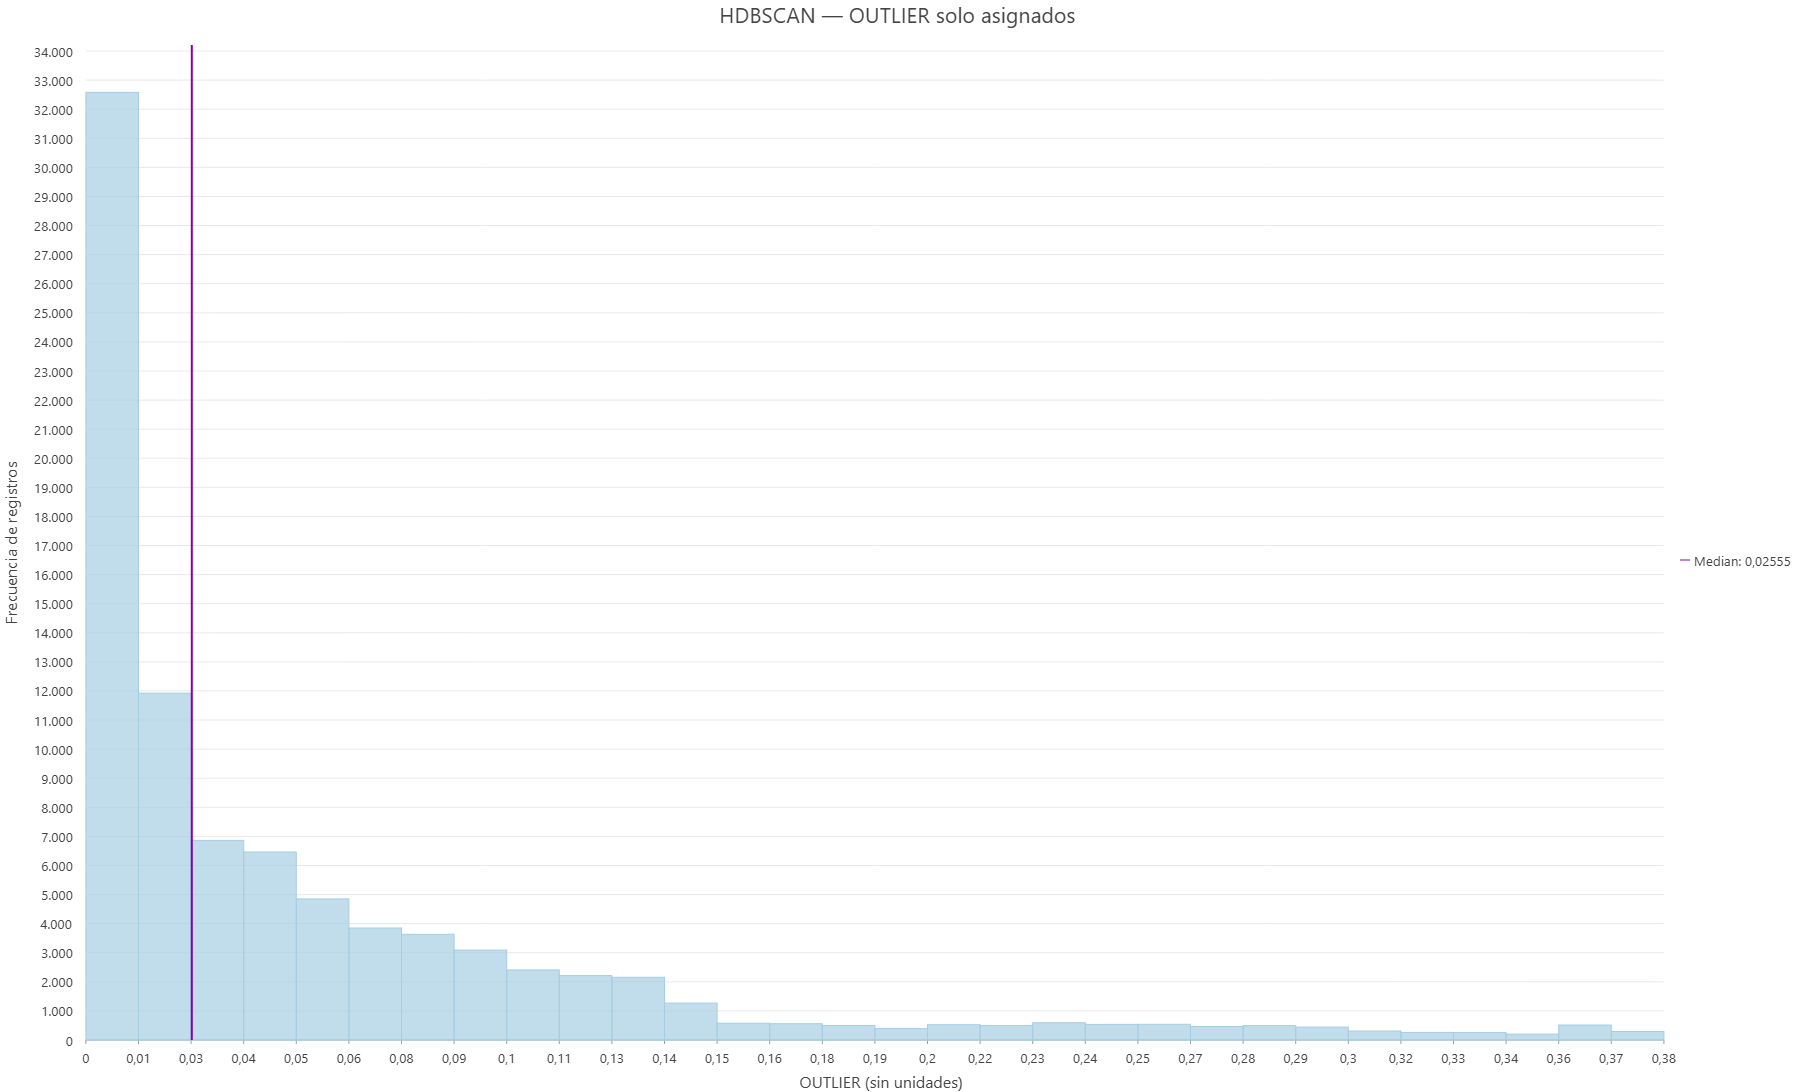

**Lectura:** frecuencia por intervalo entre asignados. Valores altos de PROB no son significancia; OUTLIER describe atipicidad respecto de la estructura del método.

**Observado:** mediana PROB 1.0000; 86,731 de 89,256 asignados tienen PROB ≥ 0.9. Esto caracteriza pertenencia interna, no valida la calidad de las coordenadas ni predice riesgo.

In [22]:
# Restringir la vista de histogramas, nunca eliminar el ruido de la salida completa.
hd_asignados = arcpy.management.MakeFeatureLayer(HDBSCAN, 'hdbscan_asignados', 'CLUSTER_ID <> -1').getOutput(0)
with arcpy.da.SearchCursor(hd_asignados, ['PROB','OUTLIER','EXEMPLAR']) as cursor:
    atributos_hd = pd.DataFrame(list(cursor), columns=['PROB','OUTLIER','EXEMPLAR'])
HISTOGRAMAS = {'asignados': len(atributos_hd), 'prob_validos': int(atributos_hd.PROB.notna().sum()),
    'prob_mediana': float(atributos_hd.PROB.median()), 'prob_mayor_igual_09': int((atributos_hd.PROB >= .9).sum()),
    'outlier_mediana': float(atributos_hd.OUTLIER.median())}
for campo, nombre in [('PROB','arcgis_hist_prob'), ('OUTLIER','arcgis_hist_outlier')]:
    chart = arcpy.charts.Histogram(campo, binCount=30, showMedian=True, dataSource=hd_asignados,
        title='HDBSCAN — ' + campo + ' solo asignados', xTitle=campo + ' (sin unidades)', yTitle='Frecuencia de registros')
    exportar_chart(chart, nombre, '**Lectura:** frecuencia por intervalo entre asignados. Valores altos de PROB no son significancia; OUTLIER describe atipicidad respecto de la estructura del método.')
display(Markdown(f"**Observado:** mediana PROB {HISTOGRAMAS['prob_mediana']:.4f}; {HISTOGRAMAS['prob_mayor_igual_09']:,} de {HISTOGRAMAS['asignados']:,} asignados tienen PROB ≥ 0.9. Esto caracteriza pertenencia interna, no valida la calidad de las coordenadas ni predice riesgo."))

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** 77 059 registros asignados dieron 20 centros promediando X e Y. Es posición media, no medoid (punto observado) ni estación óptima; puede caer fuera de una forma no convexa. ¿Se incorporó severidad o red vial? No.

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** Mediana PROB=1: al menos la mitad de valores asignados alcanza esa pertenencia interna, no 100 % de certeza territorial. OUTLIER alto indica atipicidad relativa al método, no causa ni confianza; ejes adimensionales y barras de registros asignados. EXEMPLAR identifica representantes del método, no eventos verdaderos certificados. ¿Por qué excluir ruido solo de histogramas cambia el denominador?

## 5. OPTICS: orden y alcanzabilidad
OPTICS organiza puntos de acuerdo con relaciones de densidad y usa el perfil de alcanzabilidad para extraer grupos. El eje horizontal es el **orden algorítmico**, no tiempo ni coordenada; el vertical es distancia de alcanzabilidad. Valles indican tramos conectados a distancias menores; picos separan estructuras o pueden acompañar ruido, pero un pico aislado no equivale automáticamente a un evento anómalo.

Se usa mínimo 100 y distancia máxima de búsqueda 350 m. **Se omite cluster_sensitivity:** ArcGIS selecciona su valor automáticamente; no se fija un porcentaje supuesto. La distancia limita la búsqueda del perfil, no el tamaño total de los grupos.

Esri, Pro 3.6, Density-based Clustering (enlace §3), Parameters; además ayuda Python instalada 3.6.2, cluster_sensitivity: selección automática mediante divergencia Kullback–Leibler cuando se omite, consultada el 2026-09-15.

Base en línea: Light Gray Canvas | Esri y colaboradores; atribución dentro del mapa.


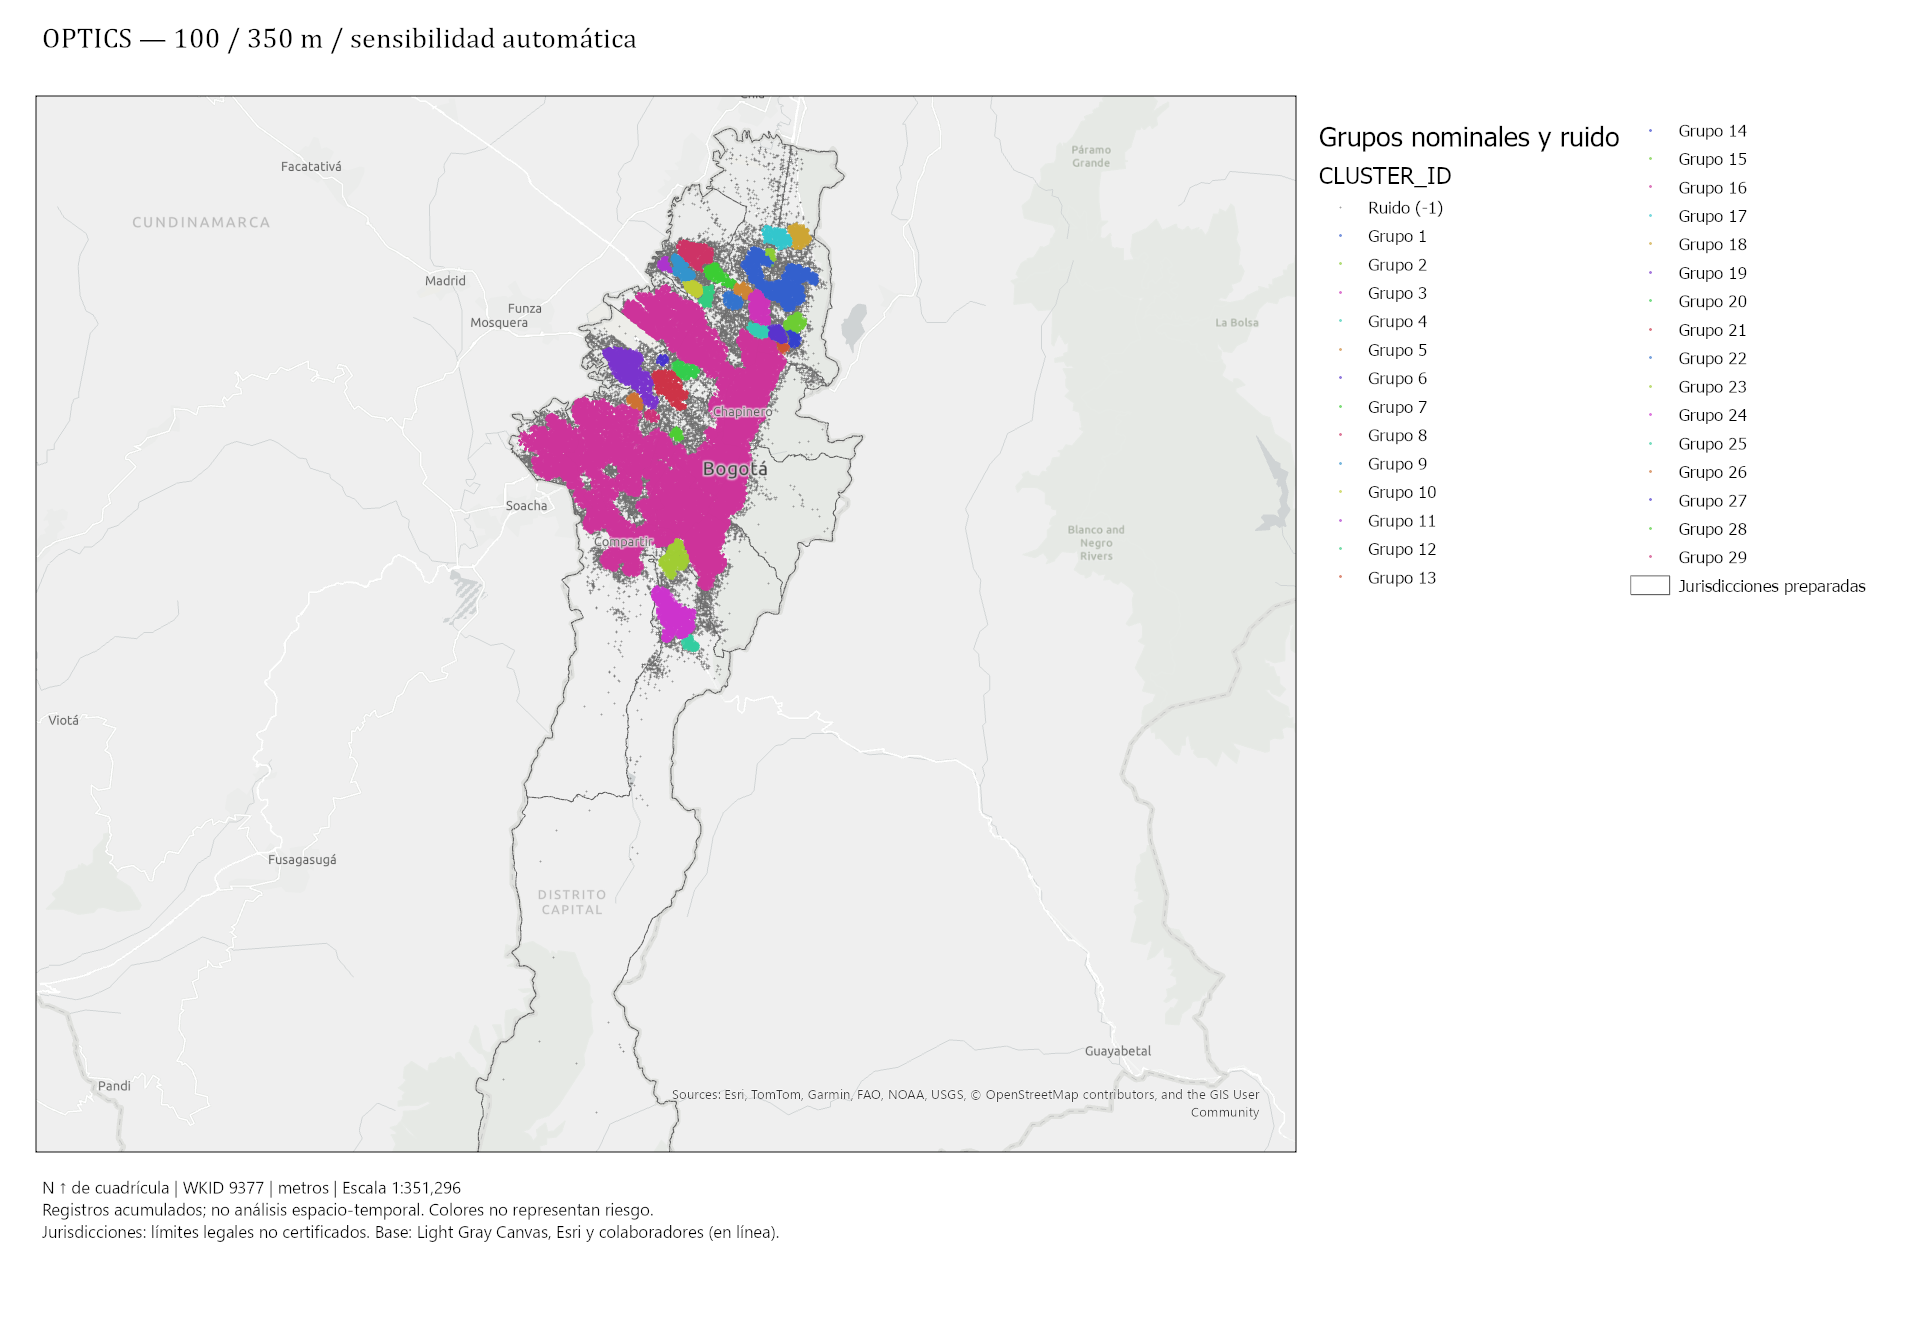

**Lectura:** grupos extraídos del perfil de alcanzabilidad; compare con los otros métodos sin equiparar etiquetas numéricas.

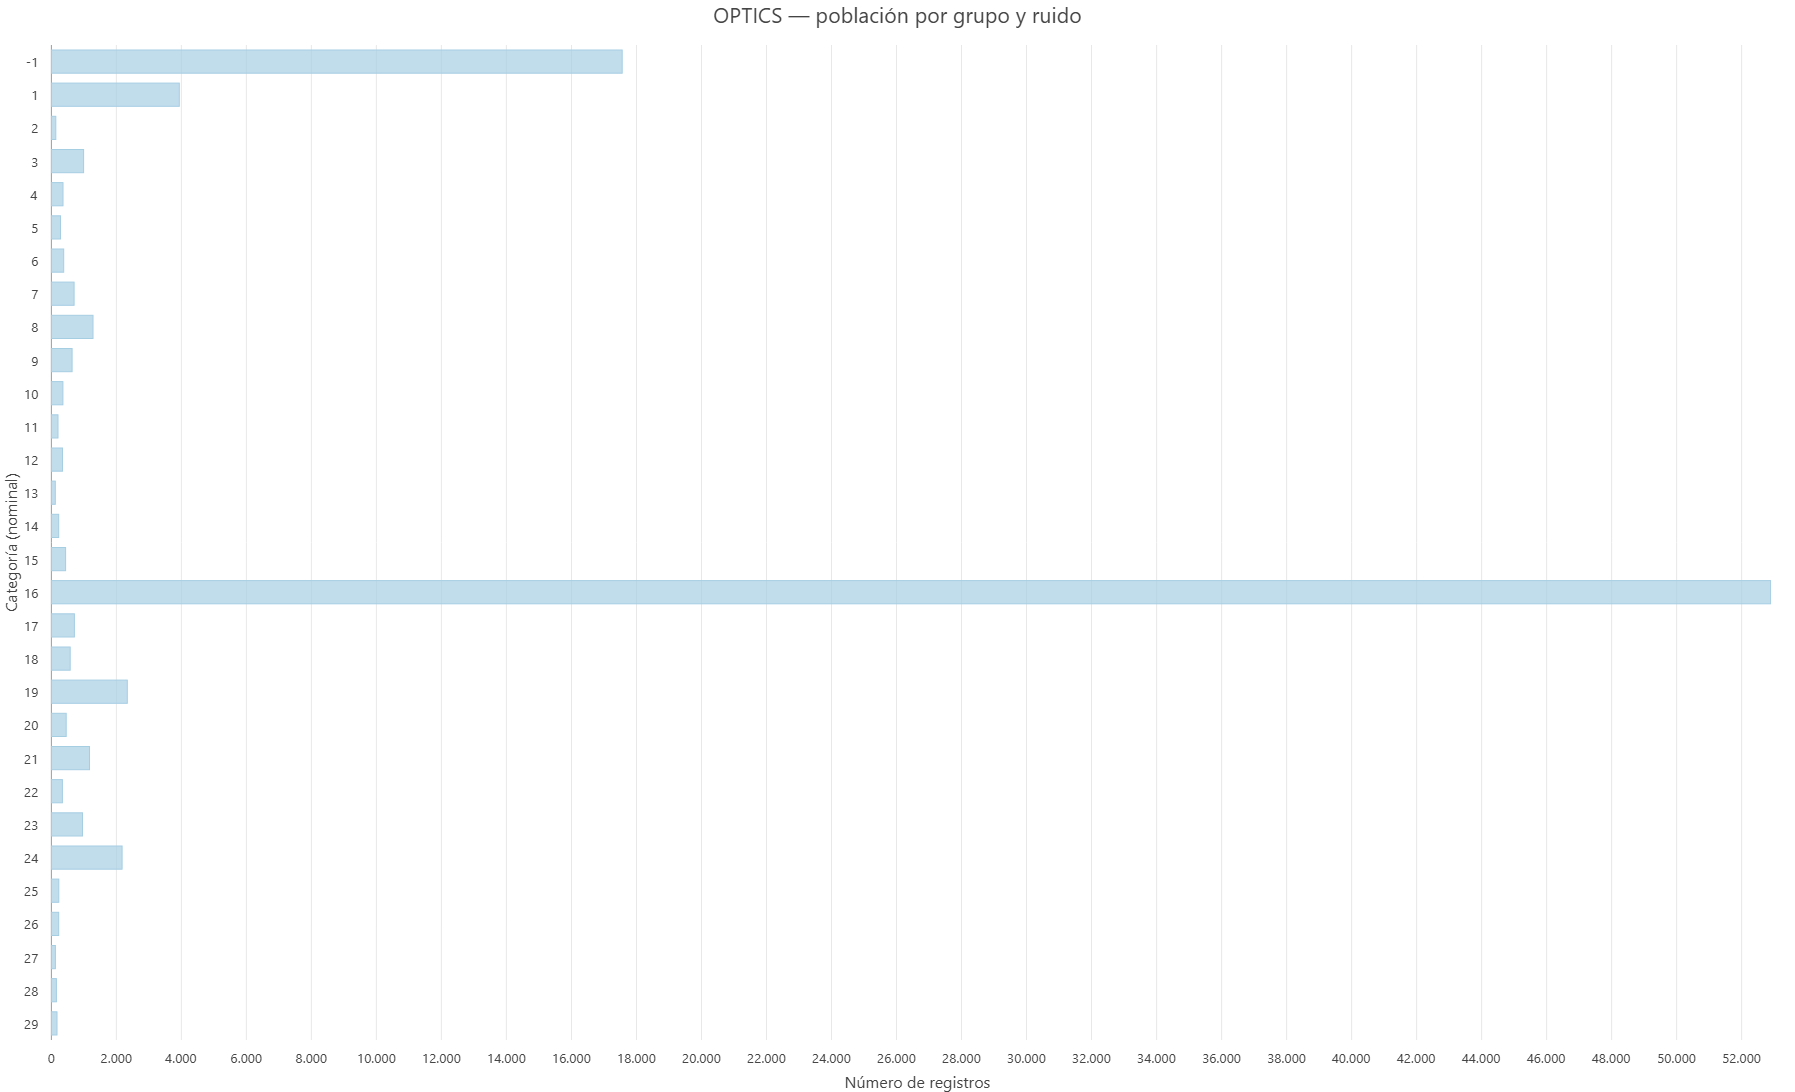

**Lectura:** el grupo dominante se identifica por el conteo observado, no por una etiqueta esperada. La sensibilidad automática depende de estos datos.

{'filas': 90443,
 'clusters': 29,
 'ruido': 17561,
 'porcentaje_ruido': 19.416649160244575,
 'mayor_cluster': 52889,
 'conteos': {-1: 17561,
  1: 3935,
  2: 134,
  3: 992,
  4: 357,
  5: 280,
  6: 379,
  7: 699,
  8: 1279,
  9: 638,
  10: 354,
  11: 202,
  12: 340,
  13: 120,
  14: 226,
  15: 438,
  16: 52889,
  17: 708,
  18: 579,
  19: 2335,
  20: 454,
  21: 1172,
  22: 337,
  23: 956,
  24: 2175,
  25: 228,
  26: 225,
  27: 124,
  28: 155,
  29: 172}}

In [23]:
# La llamada omite sensibilidad y tiempo: OPTICS espacial con sensibilidad automática.
OPTICS = str(GDB / 'IncidentesBomberosOPTICS')
medir('OPTICS', arcpy.stats.DensityBasedClustering, PUNTOS, OPTICS, 'OPTICS', 100, '350 Meters')
OP, METRICAS['OPTICS'] = etiquetas(OPTICS)
mapa_png(OPTICS, 'arcgis_mapa_optics', 'OPTICS — 100 / 350 m / sensibilidad automática',
    '**Lectura:** grupos extraídos del perfil de alcanzabilidad; compare con los otros métodos sin equiparar etiquetas numéricas.', True)
barras(METRICAS['OPTICS']['conteos'], 'arcgis_poblacion_optics', 'OPTICS — población por grupo y ruido',
    '**Lectura:** el grupo dominante se identifica por el conteo observado, no por una etiqueta esperada. La sensibilidad automática depende de estos datos.')
display(METRICAS['OPTICS'])

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** OPTICS produjo 29 grupos, 17 561 ruidos (19.416649 %) y grupo mayor de 52 889. El mensaje eligió sensibilidad 1 automáticamente, sin prefijarla. Conclusión: otra extracción, no riesgo. ¿Por qué sensibilidad no es porcentaje de confianza?

### Perfil de alcanzabilidad con los campos generados
Antes de construir el gráfico se inspecciona el esquema de salida y se identifican sus campos reales de orden y alcanzabilidad. No se confunde el OBJECTID con el orden OPTICS. Los valores nulos o negativos se registran como no representables: nunca se sustituyen por cero, pues inventarían valles. La tabla original se conserva completa.

Referencia de gráfico: **Esri, ayuda Python instalada Pro 3.6.2**, `arcpy.charts.Line`, x/y/aggregation/dataSource, consultada el 2026-09-15: x numérico o fecha, y numérico; sin agregación se representan los valores individuales. El perfil es nativo ArcGIS, no una sustitución gráfica externa.

,Campo,Alias,Tipo
0,OBJECTID,OBJECTID,OID
1,Shape,Shape,Geometry
2,SOURCE_ID,Source ID,Integer
3,CLUSTER_ID,Cluster ID,Integer
4,REACHORDER,Reachability Order,Integer
5,REACHDIST,Reachability Distance,Double
6,COLOR_ID,Color ID,Integer


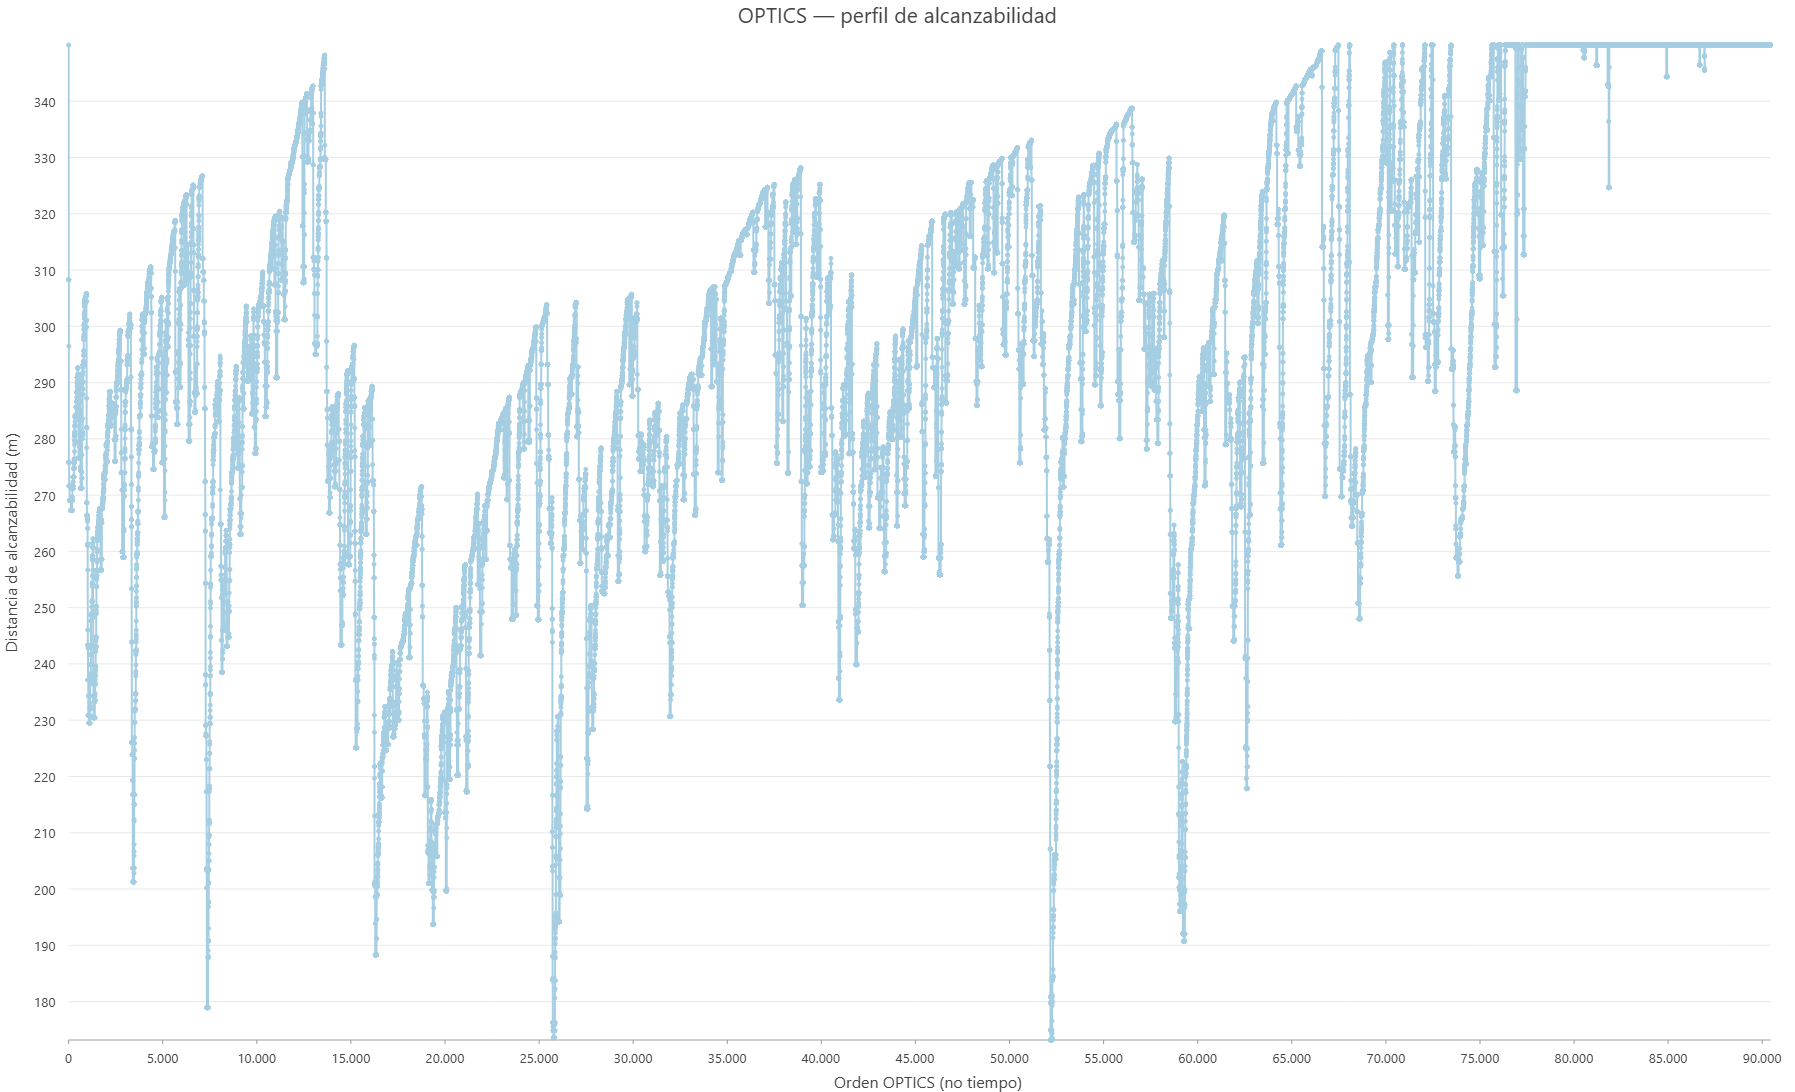

**Lectura:** valles = tramos conectados a menor distancia; picos = separaciones de densidad. El orden no es una trayectoria geográfica. No se transformaron valores ausentes en ceros.

{'campo_orden': 'REACHORDER',
 'campo_distancia': 'REACHDIST',
 'filas': 90443,
 'no_representables': 0}

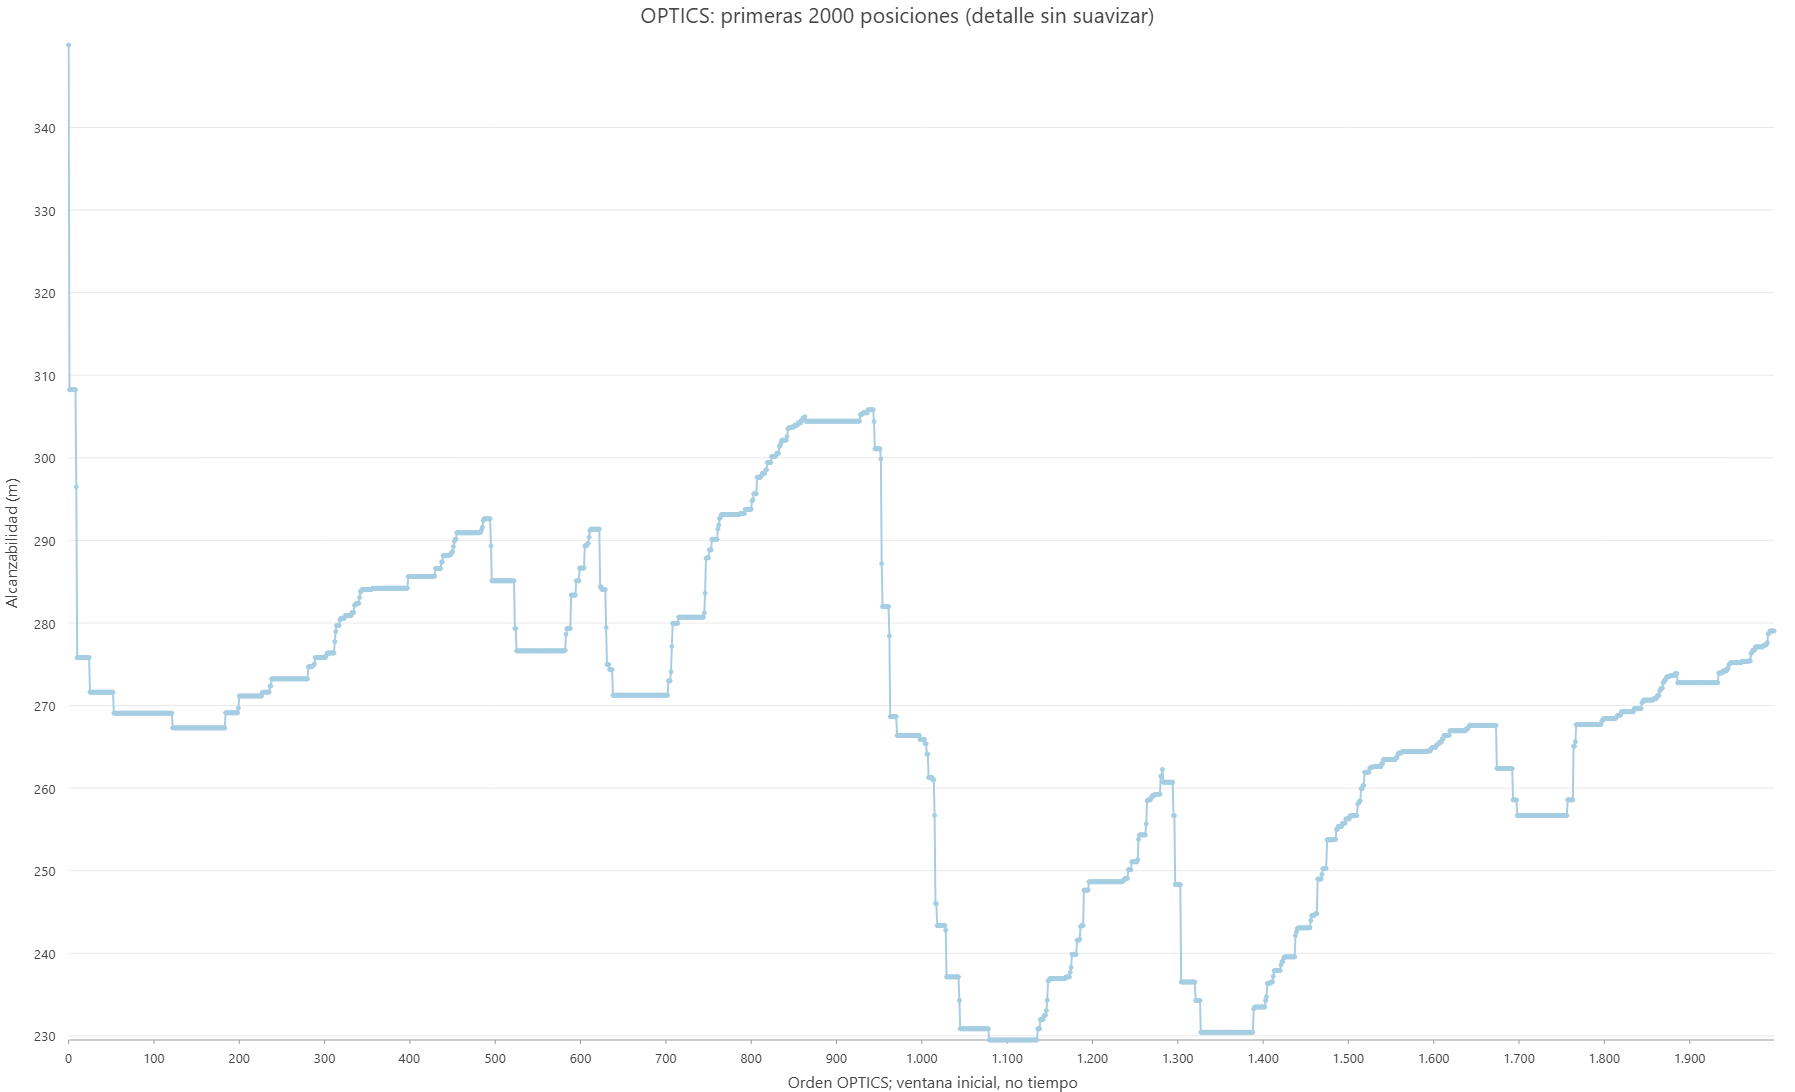

**Lectura:** ventana inicial, no selección del mejor grupo. Consulte el perfil completo y el CSV; los huecos no son ceros.

In [24]:
# Descubrir campos generados, exigir un orden único y preservar distancias ausentes como huecos.
fields_optics = arcpy.ListFields(OPTICS)
display(pd.DataFrame([(f.name,f.aliasName,f.type) for f in fields_optics], columns=['Campo','Alias','Tipo']))
ordenes = [f.name for f in fields_optics if 'ORDER' in f.name.upper() and f.type in ('Integer','SmallInteger','Double','BigInteger')]
alcances = [f.name for f in fields_optics if 'REACH' in f.name.upper() and 'DIST' in f.name.upper()]
if len(ordenes) != 1 or len(alcances) != 1:
    raise RuntimeError('Esquema de alcanzabilidad ambiguo; no se infieren campos.')
ORDEN, ALCANCE = ordenes[0], alcances[0]
with arcpy.da.SearchCursor(OPTICS, [ORDEN, ALCANCE, 'CLUSTER_ID']) as cursor:
    perfil_optics = pd.DataFrame(list(cursor), columns=['Orden','Alcanzabilidad_m','Grupo'])
if not perfil_optics.Orden.is_unique or perfil_optics.Orden.isna().any():
    raise RuntimeError('El orden OPTICS no es una clave completa.')
perfil_optics = perfil_optics.sort_values('Orden')
invalidos = perfil_optics.Alcanzabilidad_m.isna() | ~perfil_optics.Alcanzabilidad_m.map(lambda v: math.isfinite(v) if pd.notna(v) else False) | (perfil_optics.Alcanzabilidad_m < 0)
ALCANZABILIDAD = {'campo_orden': ORDEN, 'campo_distancia': ALCANCE, 'filas': len(perfil_optics), 'no_representables': int(invalidos.sum())}
perfil_optics.loc[invalidos, 'Alcanzabilidad_m'] = float('nan')
perfil_csv = RUN / 'perfil_alcanzabilidad.csv'
perfil_optics.to_csv(perfil_csv, index=False, encoding='utf-8-sig')
chart = arcpy.charts.Line(x='Orden', y='Alcanzabilidad_m', dataSource=str(perfil_csv), nullPolicy='null',
    title='OPTICS — perfil de alcanzabilidad', xTitle='Orden OPTICS (no tiempo)', yTitle='Distancia de alcanzabilidad (m)')
exportar_chart(chart, 'arcgis_alcanzabilidad', '**Lectura:** valles = tramos conectados a menor distancia; picos = separaciones de densidad. El orden no es una trayectoria geográfica. No se transformaron valores ausentes en ceros.')
display(ALCANZABILIDAD)
# Ventana inicial explícita; el panel anterior conserva el perfil ordenado completo.
detalle = perfil_optics.iloc[:min(2000, len(perfil_optics))]
detalle_path = RUN / 'perfil_alcanzabilidad_detalle.csv'
detalle.to_csv(detalle_path, index=False, encoding='utf-8-sig')
chart = arcpy.charts.Line(x='Orden', y='Alcanzabilidad_m', dataSource=str(detalle_path), nullPolicy='null',
    title='OPTICS: primeras 2000 posiciones (detalle sin suavizar)',
    xTitle='Orden OPTICS; ventana inicial, no tiempo', yTitle='Alcanzabilidad (m)')
exportar_chart(chart, 'arcgis_alcanzabilidad_detalle',
    '**Lectura:** ventana inicial, no selección del mejor grupo. Consulte el perfil completo y el CSV; los huecos no son ceros.')


**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** REACHORDER/REACHDIST: 90 443 valores representables y 0 no representables. X=orden algorítmico, Y=alcanzabilidad en metros; SOURCE_ID enlaza entrada, no ordena recorrido. Valles sugieren estructura densa, no serie temporal ni ruta de bomberos. ¿Qué valles falsos produciría imputar cero?

## 6. Comparación y revisión
La evaluación no supervisada combina coherencia espacial, distribución de tamaños, ruido y conocimiento del dominio: no hay aquí etiquetas verdaderas para medir exactitud. Menos ruido no garantiza mejor segmentación. Una comparación por pares asignados evita exigir igualdad de números de grupo; excluye ruido como conjunto porque no forma un grupo real.

**Preguntas de revisión:**
- ¿Por qué 350 m no limita el diámetro de un grupo DBSCAN? Por conectividad encadenada de vecindades.
- ¿Qué cambia con HDBSCAN? Extrae estructuras persistentes de densidad variable sin un único epsilon fijo.
- ¿Qué muestra OPTICS? Un orden y distancias de alcanzabilidad, anteriores a la extracción de grupos.
- ¿Puede un centro resumir una concentración no convexa fuera de sus puntos? Sí; es una media, no un punto óptimo de servicio.
- ¿Se pueden sumar conteos tras Identity si hay varias coincidencias? No sin resolver explícitamente la unidad de análisis: repetirían población del mismo grupo.

**Límites:** registros acumulados, sin ajuste poblacional, red vial, severidad, causalidad ni validación temporal; no se certifica jurisdicción legal. Las posiciones repetidas se conservan y pueden influir en densidad. No se eliminan automáticamente ni se reinterpretan como duplicados.

In [25]:
# Comparación invariante al número de etiqueta, enlazada por SOURCE_ID verificado.
def comparar(a, b):
    merged = a.merge(b, on='SOURCE_ID', validate='one_to_one', suffixes=('_a','_b'))
    pares = lambda n: int(n)*(int(n)-1)//2
    ambos = merged[(merged.CLUSTER_ID_a != -1) & (merged.CLUSTER_ID_b != -1)]
    interseccion = sum(pares(n) for n in ambos.groupby(['CLUSTER_ID_a','CLUSTER_ID_b']).size())
    total_a = sum(pares(n) for n in a[a.CLUSTER_ID != -1].groupby('CLUSTER_ID').size())
    total_b = sum(pares(n) for n in b[b.CLUSTER_ID != -1].groupby('CLUSTER_ID').size())
    union = total_a + total_b - interseccion
    return {'filas_enlazadas': len(merged), 'jaccard_copertenencia': interseccion/union if union else None}
COMPARACION = {'DBSCAN_HDBSCAN': comparar(DB, HD), 'DBSCAN_OPTICS': comparar(DB, OP), 'HDBSCAN_OPTICS': comparar(HD, OP)}
resumen = pd.DataFrame([{**{k:v for k,v in datos.items() if k != 'conteos'}, 'metodo': metodo,
    'segundos_modelo': TIEMPOS[metodo]} for metodo,datos in METRICAS.items()])
display(resumen)
display(COMPARACION)
display(Markdown('**Conclusión:** las tres salidas conservan las mismas claves técnicas. Las diferencias de grupos y ruido describen definiciones de densidad distintas; los índices de co-pertenencia son acuerdos entre particiones, no exactitud contra verdad territorial.'))

,filas,clusters,ruido,porcentaje_ruido,mayor_cluster,metodo,segundos_modelo
0,90443,20,13384,14.798271,67478,DBSCAN,6.585258
1,90443,3,1187,1.312429,88919,HDBSCAN,51.010935
2,90443,29,17561,19.416649,52889,OPTICS,25.508324


{'DBSCAN_HDBSCAN': {'filas_enlazadas': 90443,
  'jaccard_copertenencia': 0.5775689341249255},
 'DBSCAN_OPTICS': {'filas_enlazadas': 90443,
  'jaccard_copertenencia': 0.6199117861058122},
 'HDBSCAN_OPTICS': {'filas_enlazadas': 90443,
  'jaccard_copertenencia': 0.3580417895526128}}

**Conclusión:** las tres salidas conservan las mismas claves técnicas. Las diferencias de grupos y ruido describen definiciones de densidad distintas; los índices de co-pertenencia son acuerdos entre particiones, no exactitud contra verdad territorial.

**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** Jaccard de copertenencia=intersección/unión de pares asignados juntos: 0 sin coincidencia, 1 coincidencia completa. DBSCAN–HDBSCAN=0.577569; DBSCAN–OPTICS=0.619912; HDBSCAN–OPTICS=0.358042. Es adimensional, excluye ruido como grupo y no mide exactitud. ¿Mayor acuerdo implica verdad territorial?

## 7. Evidencia de esta ejecución
Los resultados siguientes se calculan en el kernel actual. Se guardan parámetros, etapas, tiempos, métricas, nombres exactos de figuras y comparaciones de integridad. El tiempo medido no es una prueba de que la práctica quepa en una agenda docente. Los APRX permiten inspección local complementaria; no se publica ningún dato.

**Revisión observada, ejecución vigente `ejecucion_20260915T220908_d62e311d`:** 25 celdas de código completadas sin errores; 355.40 s de kernel y 333.30 s de operaciones. Se conservan 13 PNG nativos: cuatro mapas, seis barras, dos histogramas y un perfil de alcanzabilidad. Los cuatro mapas y las barras de estación se abrieron después de mejorar el espaciado del pie y usar códigos B-1 a B-17 completos. Los otros ocho PNG son idénticos píxel a píxel a los ya abiertos en la ejecución previa preservada. Títulos, ejes y leyendas legibles; los nombres completos de estación permanecen en tabla y CSV. Los grupos pequeños se comprimen en la escala lineal: usar sus conteos tabulados y APRX para detalle. Las jurisdicciones del extremo sur pueden continuar fuera del encuadre común de los incidentes. No se afirma cobertura cartográfica completa del polígono. Se corrigió además la detección de ROOT para permitir configurar rutas externas fuera del vault; no depende de otra carpeta de datos cuando se cambian las entradas.

**Interpretación final:** HDBSCAN concentra 88 919 filas en su grupo 2 y deja 1 187 como ruido; PROB tiene mediana 1, sin equivaler a verdad territorial. OPTICS genera 29 grupos y 17 561 registros ruidosos, con grupo 16 dominante (52 889). El mensaje de la herramienta informó sensibilidad elegida 1, segunda opción 0; la llamada omitió el parámetro, no lo prefijó. El perfil utiliza REACHORDER/REACHDIST y 90 443 valores representables: valles de densidad y tramos altos cercanos al límite de búsqueda de 350 m, no una trayectoria temporal. No se altera la distancia ni la sensibilidad para reproducir una imagen esperada.

**Procedencia del procedimiento:** Esri Colombia, *DiplomadoGeoIA Ejercicio 5A — Clustering basado en densidad*, edición estudiante, pasos 1–5 y revisión; DOCX local leído el 2026-09-15. La automatización conserva selección, centro medio, Identity, COUNT, unión, copia y tres métodos. Sus cifras impresas no se reutilizan como resultados actuales. Las referencias oficiales enlazadas y la ayuda instalada respaldan las operaciones; no se afirma consulta web nueva para la ayuda local.

**Insumo jurisdiccional:** copia preparada fuera de esta práctica; el notebook únicamente la comprueba y la consume. Cero problemas detectados no equivale a certificación cartográfica o legal.

In [26]:
# Cerrar evidencia solo si los originales, la jurisdicción preparada y la plantilla no cambiaron.
HASHES_DESPUES = {k: fingerprint(p) for k,p in ENTRADAS.items()}
coinciden = HASHES_ANTES == HASHES_DESPUES
(RUN / 'integridad_notebook_despues.json').write_text(json.dumps({'run_id': RUN.name, 'hashes': HASHES_DESPUES, 'coinciden': coinciden}, indent=2), encoding='utf-8')
if not coinciden:
    raise RuntimeError('Integridad de entradas no demostrada; no se declara éxito.')
EVIDENCIA = {'run_id': RUN.name, 'estado': 'ejecutado', 'autonomo': True, 'runtime': ENTORNO,
    'segundos': time.perf_counter()-inicio, 'tiempos_herramientas': TIEMPOS, 'png': PNG,
    'parametros': {'DBSCAN': {'minimo':100,'distancia_m':350}, 'HDBSCAN': {'minimo':100},
                   'OPTICS': {'minimo':100,'distancia_m':350,'sensibilidad':'automatica_omitida'}},
    'perfil_antes': PERFIL_ANTES, 'perfil_despues': PERFIL_DESPUES, 'geometria': GEOMETRIA,
    'jurisdicciones': len(jurisdicciones), 'centros': DIAGNOSTICO_CENTROS, 'conteos_centros': poblacion_grupos,
    **METRICAS, 'histogramas_asignados': HISTOGRAMAS, 'alcanzabilidad': ALCANZABILIDAD,
    'comparacion': COMPARACION, 'hashes_antes': HASHES_ANTES, 'hashes_despues': HASHES_DESPUES,
    'aprx': sorted(p.name for p in RUN.glob('*.aprx'))}
(RUN / 'evidencia.json').write_text(json.dumps(EVIDENCIA, ensure_ascii=False, indent=2), encoding='utf-8')
display(pd.DataFrame(sorted(TIEMPOS.items()), columns=['Operación','Segundos observados']))
print('Ejecución:', RUN.name, '| Entradas íntegras:', coinciden, '| PNG nativos:', len(PNG))
print('Archivos visuales:', PNG)

Ejecución: ejecucion_20260916T221040_d407aea3 | Entradas íntegras: True | PNG nativos: 14
Archivos visuales: ['arcgis_estaciones.png', 'arcgis_jurisdicciones.png', 'arcgis_anios.png', 'arcgis_mapa_entrada.png', 'arcgis_mapa_dbscan.png', 'arcgis_poblacion_dbscan.png', 'arcgis_mapa_hdbscan.png', 'arcgis_poblacion_hdbscan.png', 'arcgis_hist_prob.png', 'arcgis_hist_outlier.png', 'arcgis_mapa_optics.png', 'arcgis_poblacion_optics.png', 'arcgis_alcanzabilidad.png', 'arcgis_alcanzabilidad_detalle.png']


,Operación,Segundos observados
0,AddJoin,0.276161
1,CheckGeometry_jurisdicciones_preparadas,0.641315
2,CheckGeometry_puntos,1.437992
3,CopyFeatures_centros,0.362367
4,CopyFeatures_entrada,4.729740
5,DBSCAN,6.585258
6,FieldStatisticsToTable,2.261345
7,HDBSCAN,51.010935
8,Identity,0.701650
9,MeanCenter,4.866268


**Lectura histórica conservada — referencia histórica; cotejar con salida actual.** 13 figuras e integridad True documentan aquella corrida. Duraciones son segundos de cómputo, por ejemplo HDBSCAN 122.761505; no agenda ni ejecución nueva. Conclusión: evidencia histórica conservada, referencia histórica; cotejar con salida actual. ¿Cero errores de celda prueba cierre natural del proceso?